# Module-1: Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

## Part-1: Data Overview

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# read data from file to a pandas dataframe
data_df = pd.read_csv("/content/drive/MyDrive/Twitter.csv")

In [ ]:
# check the shape of the data frame
data_df.shape

(500036, 6)

In [ ]:
# get an overview of the top-5 rows/samples
data_df.head()

,date,id,content,username,like_count,retweet_count
0,2023-03-29 22:58:21+00:00,1641213230730051584,"Free AI marketing and automation tools, strate...",RealProfitPros,0.0,0.0
1,2023-03-29 22:58:18+00:00,1641213218520481805,@MecoleHardman4 Chat GPT says it’s 15. 😂,AmyLouWho321,0.0,0.0
2,2023-03-29 22:57:53+00:00,1641213115684536323,https://t.co/FjJSprt0te - Chat with any PDF!\n...,yjleon1976,0.0,0.0
3,2023-03-29 22:57:52+00:00,1641213110915571715,"AI muses: ""In the court of life, we must all f...",ChatGPT_Thinks,0.0,0.0
4,2023-03-29 22:57:26+00:00,1641213003260633088,Most people haven't heard of Chat GPT yet.\nFi...,nikocosmonaut,0.0,0.0


To focus the analysis on the immediate impact of GPT-4 release, I filter the dataset to a ±2-week window around March 14, 2023 (March 1–27). This ensures a more controlled comparison — tweets before (Mar 1–13) and after (Mar 14–27) the release share similar linguistic patterns and platform context, minimizing confounding factors such as temporal domain shift in language and terminology.

In [ ]:
# filter to 2 weeks before and after GPT-4 release (March 14, 2023)
# before: march 1 - march 13 (2 weeks)
# after:  march 14 - march 27 (2 weeks)

data_df['date'] = pd.to_datetime(data_df['date'], errors='coerce')  # convert the timestamp to readable date
data_df = data_df[(data_df['date'] >= '2023-03-01') & (data_df['date'] <= '2023-03-27')].reset_index(drop=True)

print(f"Filtered date range: {data_df['date'].min().date()} to {data_df['date'].max().date()}")
print(f"Total tweets: {len(data_df)}")
print(f"Before GPT-4 (Mar 1-13):  {len(data_df[data_df['date'] < '2023-03-14'])}")
print(f"After GPT-4  (Mar 14-27): {len(data_df[data_df['date'] >= '2023-03-14'])}")

Filtered date range: 2023-03-01 to 2023-03-27
Total tweets: 166416
Before GPT-4 (Mar 1-13):  63919
After GPT-4  (Mar 14-27): 102497


In [ ]:
# re-check the shape of the data frame
data_df.shape

(166416, 6)

In [ ]:
# get an overview of the top-5 rows/samples again
data_df.head()

,date,id,content,username,like_count,retweet_count
0,2023-03-27 00:00:00+00:00,1640141583055036419,ChatGPT leaks bits of users' chat history http...,nTangledCloud,1.0,2.0
1,2023-03-26 23:59:01+00:00,1640141335616270336,The Future of Chat is Here: GPT-3 and Its Impa...,delf_ron,0.0,0.0
2,2023-03-26 23:58:52+00:00,1640141299948060672,AI Researcher Goaded Chat GPT to Attempt to Ja...,SardarKhalsa1,0.0,0.0
3,2023-03-26 23:58:47+00:00,1640141278754258946,🚨Get Out!🚨\n💰#Binance Spot💰\n⬇ Recommendation:...,bitone_great,0.0,0.0
4,2023-03-26 23:58:37+00:00,1640141234848296961,To *gpt*.\nThe #ChatGPT processing based on fi...,QiongDad,0.0,0.0


In this dataset, approximately 10,000 samples were labeled using an LLM (Claude). The label distribution is as follows: Claude — {'neutral': 43.15%, 'positive': 37.58%, 'negative': 19.27%}. See Module 2 (Supervised Learning), Part 1, Section 1.5: Sentiment Visualization for details.

These 10,000 samples were split into 70% training, 10% validation, and 20% testing sets.

<mark> See Module-2(Supervised Learning) Part-1 1.5 **target variable exploration** for details<mark/>

## Part-2: Data Cleaning

In [ ]:
# check missing values
null_sum = data_df.isnull().sum()
null_sum

,0
date,0
id,0
content,0
username,4
like_count,4
retweet_count,4


In [ ]:
# drop columns that have at least 30% missing values
data_df.drop(columns=data_df.columns[null_sum > len(data_df) * 0.3], inplace=True)

# check the shape and columns of the cleaned data frame
data_df.shape, data_df.columns      # remain the same, no data has been deleted

((166416, 6),
 Index(['date', 'id', 'content', 'username', 'like_count', 'retweet_count'], dtype='object'))

## Part-3: Text Data Processing

This research focuses on text content analysis to study public sentiment and discussion topics, so only one feature(text/content) here.
Other columns (e.g., like_count, retweet_count) are not relevant to the NLP tasks.

In [ ]:
data_df[["content"]]

,content
0,ChatGPT leaks bits of users' chat history http...
1,The Future of Chat is Here: GPT-3 and Its Impa...
2,AI Researcher Goaded Chat GPT to Attempt to Ja...
3,🚨Get Out!🚨\n💰#Binance Spot💰\n⬇ Recommendation:...
4,To *gpt*.\nThe #ChatGPT processing based on fi...
...,...
166411,The best part about AI in healthcare is its po...
166412,"🤖 Hey there! It's #ChatGPT, your favorite AI l..."
166413,Why was the John green book so sad? \nBecause ...
166414,Noun: victor\n\nA victor is someone who has co...


### 3.1 Text Data Cleaning

In [ ]:
# 1. check duplicates
duplicated_counts = data_df['content'].duplicated().value_counts()
duplicated_counts

,count
content,
False,164571
True,1845


In [ ]:
# 2. drop duplicates
data_df = data_df.drop_duplicates(subset=['content'], keep='first')

# reset index after dropping duplicates
data_df = data_df.reset_index(drop=True)

# check data shape after dropping duplicates
data_df['content'].shape

(164571,)

In [ ]:
# 3. check missing values
null_content = data_df['content'].isnull().sum()
null_content

np.int64(0)

In [ ]:
# 4. data cleaning

# 4.1 clean 'content' column
def clean_tweet_content(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)  # remove mentions
    text = re.sub(r'\brt\b', '', text)  # remove RT
    text = re.sub(r'#', '', text)  # remove hashtags
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces

    return text


# 4.2 apply cleaning function
data_df['content_clean'] = data_df['content'].apply(clean_tweet_content)


# 4.3 remove empty tweets after cleaning
before_clean = len(data_df)
data_df = data_df[data_df['content_clean'].str.len() > 0]
after_clean = len(data_df)

print(f"Before cleaning: {before_clean} tweets")
print(f"After cleaning: {after_clean} tweets")


# 4.4 view cleaning results
data_df[['content', 'content_clean']].head(10)

Before cleaning: 164571 tweets
After cleaning: 164571 tweets


,content,content_clean
0,ChatGPT leaks bits of users' chat history http...,chatgpt leaks bits of users chat history cyber...
1,The Future of Chat is Here: GPT-3 and Its Impa...,the future of chat is here gpt and its impact ...
2,AI Researcher Goaded Chat GPT to Attempt to Ja...,ai researcher goaded chat gpt to attempt to ja...
3,🚨Get Out!🚨\n💰#Binance Spot💰\n⬇ Recommendation:...,get out binance spot recommendation short tick...
4,To *gpt*.\nThe #ChatGPT processing based on fi...,to gpt the chatgpt processing based on fixed d...
5,🚨Short Greed!🚨\n💰#Binance Spot💰\n⬇ Recommendat...,short greed binance spot recommendation short ...
6,Everything is on WhatsApp now.\nChatgpt have t...,everything is on whatsapp now chatgpt have thi...
7,@Acerola__t im at 17 rn they just keep coming ...,im at rn they just keep coming in my tl like c...
8,"introducing ""WOB Satori"" - so You/I/chatGPT ne...",introducing wob satori so you i chatgpt never ...
9,have OpenAI already tried to improve their mod...,have openai already tried to improve their mod...


### 3.2 Tokenization + Lemmatization

In [ ]:
import nltk
from nltk import sent_tokenize
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# tokenization
data_df['content_tokens'] = data_df['content_clean'].apply(word_tokenize)

In [ ]:
# remove stop words
stop_words = set(stopwords.words('english'))

# keep important short words
important_words = {'ai', 'gpt', 'ml', 'dl', 'nlp', 'ui', 'ux', 'id'}
def remove_stopwords(tokens):
    return [word for word in tokens if (word not in stop_words and len(word) > 2) or word in important_words]

data_df['tokens_no_stop'] = data_df['content_tokens'].apply(remove_stopwords)

In [ ]:
# lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

data_df['tokens_lemma'] = data_df['tokens_no_stop'].apply(lemmatize_tokens)

In [ ]:
# reconstruct cleaned content
data_df['content_processed'] = data_df['tokens_lemma'].apply(lambda x: ' '.join(x))
data_df[['content', 'content_processed']].head(10)

,content,content_processed
0,ChatGPT leaks bits of users' chat history http...,chatgpt leak bit user chat history cybersecuri...
1,The Future of Chat is Here: GPT-3 and Its Impa...,future chat gpt impact communication chat comm...
2,AI Researcher Goaded Chat GPT to Attempt to Ja...,ai researcher goaded chat gpt attempt jailbrea...
3,🚨Get Out!🚨\n💰#Binance Spot💰\n⬇ Recommendation:...,get binance spot recommendation short ticker p...
4,To *gpt*.\nThe #ChatGPT processing based on fi...,gpt chatgpt processing based fixed document fi...
5,🚨Short Greed!🚨\n💰#Binance Spot💰\n⬇ Recommendat...,short greed binance spot recommendation short ...
6,Everything is on WhatsApp now.\nChatgpt have t...,everything whatsapp chatgpt feature collaborat...
7,@Acerola__t im at 17 rn they just keep coming ...,keep coming like chatgpt broke internet thread...
8,"introducing ""WOB Satori"" - so You/I/chatGPT ne...",introducing wob satori chatgpt never get creat...
9,have OpenAI already tried to improve their mod...,openai already tried improve model result chat...


In [ ]:
# filter out empty tweets after processing
before = len(data_df)
data_df = data_df[data_df['content_processed'].str.split().apply(len) > 0].reset_index(drop=True)
after = len(data_df)
print(f"Removed {before - after} empty tweets after processing")
print(f"Remaining: {after} tweets")

Removed 23 empty tweets after processing
Remaining: 164548 tweets


### 3.3 TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1, 2))
X = vectorizer.fit_transform(data_df['content_processed'])
X.shape

(164548, 5000)

In [ ]:
# check the extracted features during the vectorization
feature_names = vectorizer.get_feature_names_out()

In [ ]:
# find out top-20 most most frequent features
def get_topn_features(X, feature_names, topn=20):
    """
    Inputs:
        X: feature matrix
        feature_names: extracted features during vectorization
        topn: the number of most frequent features to return
    Outputs:
        topn most frequent features and their TF-IDF score
    """
    # sum TF-IDF scores across all documents
    feature_ct = np.asarray(np.sum(X, axis=0)).reshape(-1)

    feature_freq = []

    for i in np.argsort(feature_ct)[::-1][:topn]:
        feature_freq.append({'feature': feature_names[i], 'tfidf_score': feature_ct[i]})

    return pd.DataFrame(feature_freq)

get_topn_features(X, feature_names, topn=20)

,feature,tfidf_score
0,gpt,9860.285884
1,chatgpt,9849.272118
2,chat,8824.712791
3,chat gpt,8634.342574
4,ai,5839.531748
5,openai,2498.615270
6,like,1931.927325
7,use,1890.626440
8,new,1642.814874
9,using,1594.253877


## Part-4: EDA Visualization

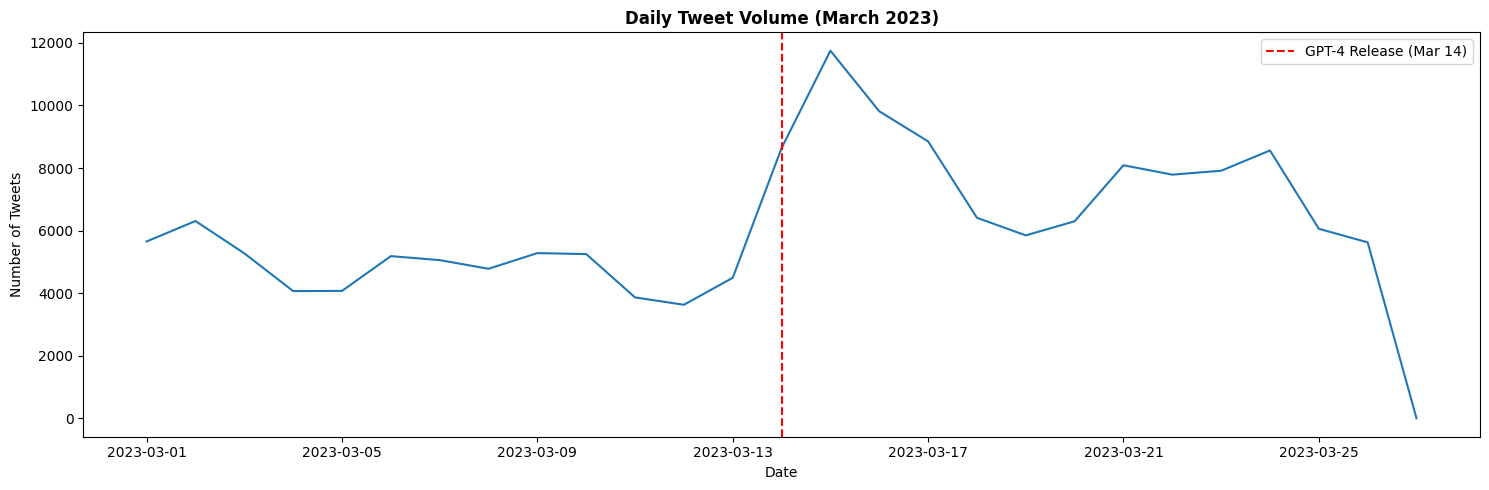

In [ ]:
# 4.1 tweet volume over time
data_df['date'] = pd.to_datetime(data_df['date'], errors='coerce')
daily_counts = data_df.groupby(data_df['date'].dt.date).size()

plt.figure(figsize=(15, 5))
daily_counts.plot()
plt.axvline(x=pd.to_datetime('2023-03-14').date(), color='red', linestyle='--', label='GPT-4 Release (Mar 14)')
plt.title('Daily Tweet Volume (March 2023)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend()
plt.tight_layout()
plt.show()

Tweet volume was relatively stable before GPT-4's release (March 14), averaging around 5,000-6000 tweets per day. Following the release, volume spiked sharply to nearly 12,000 tweets on March 15, indicating a significant surge in public attention. Volume gradually declined afterward but remained higher than pre-release levels, suggesting sustained interest in GPT-4.

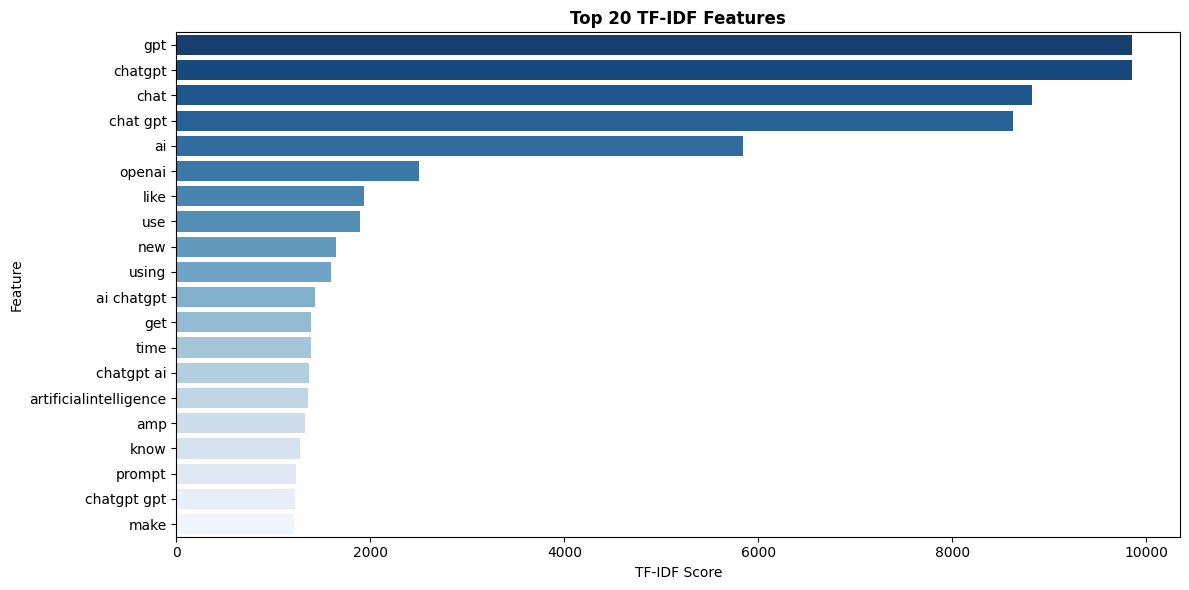

In [ ]:
# 4.2 top-20 TF-IDF features bar chart
top_features = get_topn_features(X, feature_names, topn=20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_features, x='tfidf_score', y='feature', hue='feature', palette='Blues_r', legend=False)
plt.title('Top 20 TF-IDF Features', fontweight='bold')
plt.xlabel('TF-IDF Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The most frequent features are dominated by GPT-related terms such as "gpt", "chatgpt", "chat", and "ai", which are expected given the dataset focuses on ChatGPT-related tweets. Generic terms like "like", "use", and "new" also appear frequently, reflecting common Twitter language patterns.

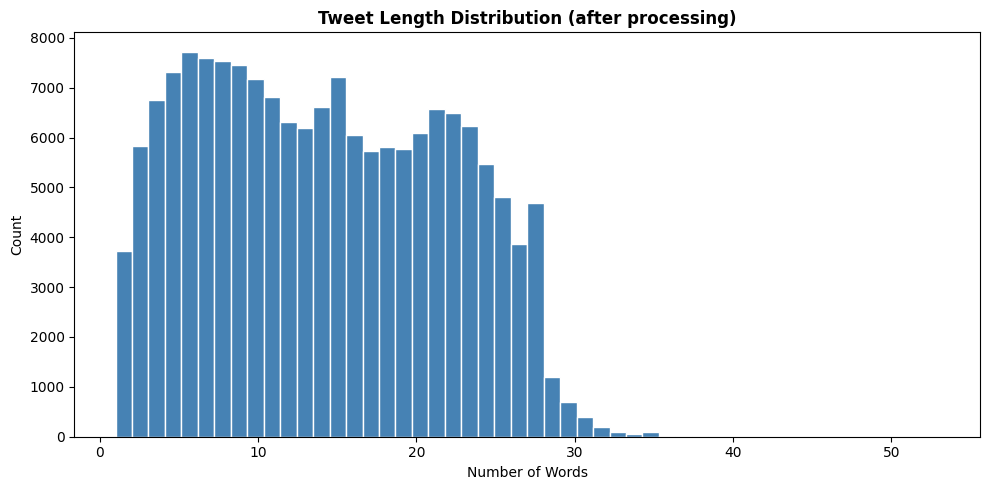

Average tweet length: 14.20 words
Max tweet length: 53 words
Min tweet length: 1 words


In [ ]:
# 4.3 tweet length distribution
data_df['text_length'] = data_df['content_processed'].str.split().apply(len)

plt.figure(figsize=(10, 5))
plt.hist(data_df['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.title('Tweet Length Distribution (after processing)', fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Average tweet length: {data_df['text_length'].mean():.2f} words")
print(f"Max tweet length: {data_df['text_length'].max()} words")
print(f"Min tweet length: {data_df['text_length'].min()} words")

After preprocessing, tweet length follows a roughly normal distribution, with an average of 14.20 words per tweet. Most tweets fall between 5 and 25 words, which is typical for short-form social media content.

## Part-5: Before vs After GPT-4 comparison

Date range: 2023-03-01 to 2023-03-27
Before GPT-4 (before Mar 14): 62910 tweets
After GPT-4 (Mar 14 onwards): 101638 tweets


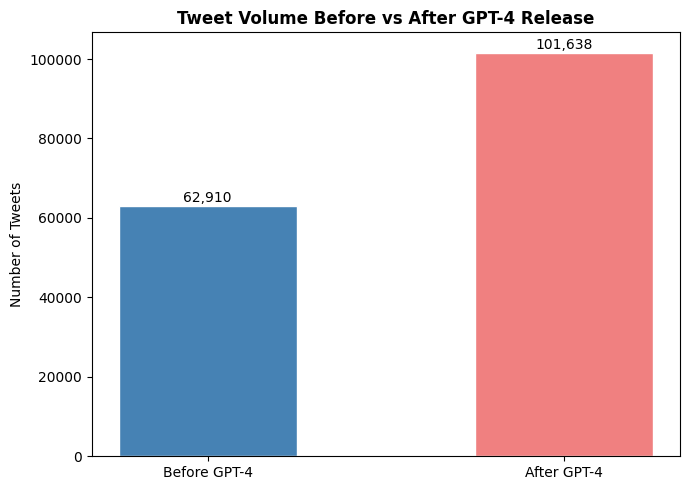

In [ ]:
## split data by GPT-4 release date (March 14, 2023)

before_gpt4 = (data_df['date'] < '2023-03-14').sum()
after_gpt4  = (data_df['date'] >= '2023-03-14').sum()

print(f"Date range: {data_df['date'].min().date()} to {data_df['date'].max().date()}")
print(f"Before GPT-4 (before Mar 14): {before_gpt4} tweets")
print(f"After GPT-4 (Mar 14 onwards): {after_gpt4} tweets")

labels = ['Before GPT-4', 'After GPT-4']
sizes = [before_gpt4, after_gpt4]
colors = ['steelblue', 'lightcoral']

plt.figure(figsize=(7, 5))
plt.bar(labels, sizes, color=colors, edgecolor='white', width=0.5)
plt.title('Tweet Volume Before vs After GPT-4 Release', fontweight='bold')
plt.ylabel('Number of Tweets')
for i, v in enumerate(sizes):
    plt.text(i, v + 1000, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

There were 62,910 tweets before GPT-4's release (March 1–13) and 101,638 tweets after (March 14–27), representing a 61.6% increase in tweet volume. This suggests that GPT-4's release significantly amplified public discussion around AI and ChatGPT.

# Module-2: Model Exploration (Unsupervised Learning)

## Part-1: Topic Modeling

### 1.1 Base BERTopic Model

In [ ]:
!pip install bertopic sentence-transformers
!pip install gensim

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [ ]:
# 1. encode embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")
embeddings = embedding_model.encode(
    data_df['content_clean'].tolist(),
    batch_size=512,
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/322 [00:00<?, ?it/s]

In [ ]:
# 2. coherence setup
import copy
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel

tokenized_docs = [doc.split() for doc in data_df['content_clean'].tolist()]
dictionary = corpora.Dictionary(tokenized_docs)

In [ ]:
# 3. fit base BERTopic model

# 3.1 domain stop words + CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

exclude_terms = [# too common
                'chatgpt', 'gpt', 'chat', 'ai', 'openai',
                 # generic terms
                 'amp', 'using', 'use', 'used', 'ask', 'asked', 'according', 'like', 'new', 'get', 'make',
                 'one', 'would', 'thing', 'say', 'people', 'time', 'think', 'know', 'via', 'getting']

custom_stop_words = list(stop_words) + exclude_terms

vectorizer_model = CountVectorizer(
    stop_words=custom_stop_words,
    ngram_range=(1, 2)
)

# 3.2 configure UMAP for dimensionality reduction(tighter local clusters)
from umap import UMAP

umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# 3.3 fit BERTopic model
base_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=40,
    calculate_probabilities=False,
    verbose=False
)
base_topics, _ = base_model.fit_transform(data_df['content_clean'].tolist(), embeddings)

n_base = len(base_model.get_topic_info()) - 1
print(f"Base model: {n_base} topics")

Base model: 493 topics


### 1.2 Model Tuning

To find optimal number of topics:

In [ ]:
# 4. coherence search loop
nr_range = list(range(5, 51, 2))
coherence_scores = []

for nr in nr_range:
    temp = copy.deepcopy(base_model)
    temp.reduce_topics(data_df['content_clean'].tolist(), nr_topics=nr)

    topics_words = [
        [w for w, _ in temp.get_topic(tid) if ' ' not in w][:10]
        for tid in range(nr)
        if temp.get_topic(tid)
    ]
    topics_words = [t for t in topics_words if t]

    cm = CoherenceModel(topics=topics_words, texts=tokenized_docs, dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())

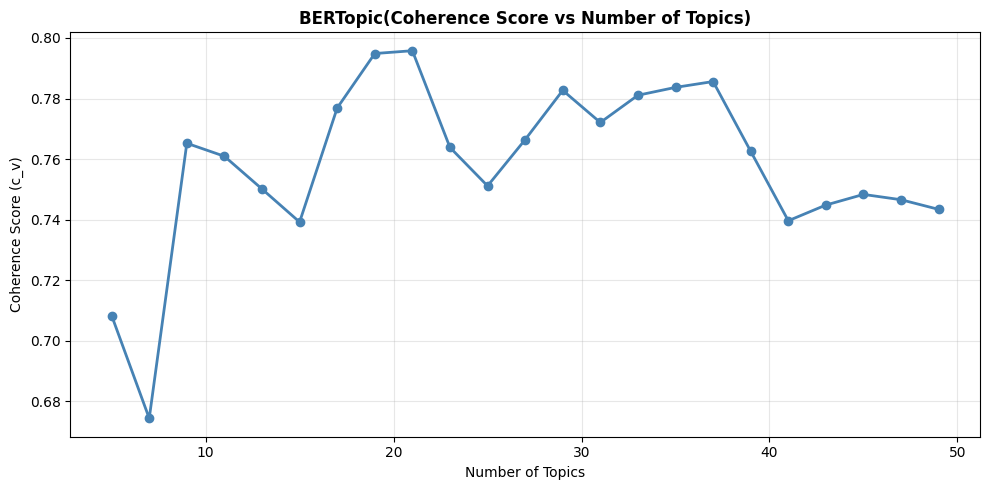

Optimal number of topics: 21


In [ ]:
# plot coherence
plt.figure(figsize=(10, 5))
plt.plot(nr_range, coherence_scores, 'o-', color='steelblue', lw=2)
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.title('BERTopic(Coherence Score vs Number of Topics)', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

optimal_nr = nr_range[int(np.argmax(coherence_scores))]
print(f"Optimal number of topics: {optimal_nr}")

In [ ]:
# 5. fit final BERTopic model
topic_model = copy.deepcopy(base_model)
topic_model.reduce_topics(data_df['content_clean'].tolist(), nr_topics=optimal_nr)
data_df['topic'] = topic_model.topics_

In [ ]:
# 6. topic diversity
all_topic_words = []
for tid in range(optimal_nr):
    topic = topic_model.get_topic(tid)
    if topic:
        all_topic_words.extend([w for w, _ in topic[:10]])

diversity = len(set(all_topic_words)) / len(all_topic_words) if all_topic_words else 0
print(f"Topic Diversity: {diversity:.4f}")

Topic Diversity: 0.9850


The topic diversity score is 0.9850, indicating that the 20 topics share very few overlapping keywords. This suggests the model has successfully identified distinct and well-separated topics, with minimal redundancy across topics.

### 1.3 Topic Overview

In [ ]:
# overview
topic_info = topic_model.get_topic_info()
topic_info[topic_info['Topic'] != -1]

,Topic,Count,Name,Representation,Representative_Docs
1,0,87057,0_google_artificialintelligence_write_bard,"[google, artificialintelligence, write, bard, ...",[gpt is times more powerful than the current c...
2,1,1656,1_trading_stocks_options_min,"[trading, stocks, options, min, trading stocks...",[me awaiting buy signal based off trades min c...
3,2,1272,2_midjourney_dalle_stablediffusion_join imagine,"[midjourney, dalle, stablediffusion, join imag...",[midjourney openai gpt stablediffusion dalle c...
4,3,905,3_domains_domain_sale_domainnames,"[domains, domain, sale, domainnames, domainfor...",[marijuanameds is for sale at domains domainna...
5,4,666,4_cows_giraffes_human_average,"[cows, giraffes, human, average, water, tongue...",[cows have best friends and they get stressed ...
6,5,289,5_resume_made simply_compelling resume_resume ...,"[resume, made simply, compelling resume, resum...",[the resume of chrispine made with ai chatgpt ...
7,6,280,6_bcm_westworld_film_blade,"[bcm, westworld, film, blade, blade runner, ru...",[i asked chatgpt what where the different thin...
8,7,209,7_sunrise sunset_sunrise_sunset_pm,"[sunrise sunset, sunrise, sunset, pm, tempupda...",[weatherupdate islamabad isb pakistan tempupda...
9,8,185,8_earth_deepest_world deepest_world,"[earth, deepest, world deepest, world, eiffel ...",[the world s deepest postbox is in susami bay ...
10,9,153,9_quantum_qam_qamai_qamai blockchain,"[quantum, qam, qamai, qamai blockchain, qam qa...",[qamai driving innovation in ai by focusing on...


In [ ]:
for tid in range(optimal_nr):
    topic = topic_model.get_topic(tid)
    if topic:
        words = [w for w, _ in topic[:20]]
        print(f"Topic {tid}: {', '.join(words)}")

Topic 0: google, artificialintelligence, write, bard, bing, technology, chatbot, microsoft, nft, tech
Topic 1: trading, stocks, options, min, trading stocks, stocks options, free trial, trial, options free, awaiting
Topic 2: midjourney, dalle, stablediffusion, join imagine, dalle join, stablediffusion dalle, midjourney stablediffusion, join, aiart, imagine
Topic 3: domains, domain, sale, domainnames, domainforsale, dao, domainnameforsale, nft, domainname, sold
Topic 4: cows, giraffes, human, average, water, tongue, sleep, mph, species, body
Topic 5: resume, made simply, compelling resume, resume click, amazing worked, wonders creating, worked wonders, creating compelling, link see, simply amazing
Topic 6: bcm, westworld, film, blade, blade runner, runner, ghost, ghost shell, shell, themes
Topic 7: sunrise sunset, sunrise, sunset, pm, tempupdate, wind speed, weatherupdate, tempupdate sunrise, sunset pm, temp humidity
Topic 8: earth, deepest, world deepest, world, eiffel tower, eiffel, t

In [ ]:
# assign theme labels
theme_labels = {
    0:  "General AI Discussion",
    1:  "Trading Signal Spam",
    2:  "AI Image Generation",
    3:  "Domain Sale Spam",
    4:  "Animal Facts Bot",
    5:  "AI Resume Generator",
    6:  "AI Film Analysis",
    7:  "Weather Update Bot",
    8:  "World Records Bot",
    9:  "Crypto Blockchain Spam",
    10: "Biotech Research",
    11: "Edu Tool Promo",
    12: "Fintech Fashion",
    13: "Oldest Things Bot",
    14: "AI Horoscopes",
    15: "AI Cybersecurity",
    16: "Premium Account Spam",
    17: "AI Robotics",
    18: "AI NFT Art",
    19: "AI Oscar NFT",
}

 Not all 20 topics are equally useful for analysis. I exclude two types:                                                                                            
                                                                                                                                                                        
  - **T0 (General AI Discussion):** Too broad, over 87,000 tweets with no specific theme (almost all about chatgpt itself). It dominates the dataset and would drown out smaller, more meaningful topics.
                  
  - **Spam/Bot Topics (T1, T3, T4, T7, T8, T9, T11, T13, T16):** These are generated by automated accounts, not real users(e.g., bots and nosise)— stock trading signals, domain sale ads,
  animal fact bots, weather bots, world record bots, crypto spam, and account promotions.

**Remaining 10 topics are kept** as they reflect genuine public discussion about specific AI use cases: image generation, resume writing, film analysis, biotech, fintech, horoscopes, cybersecurity, robotics, NFT art, and AI at the Oscars.

In [ ]:
meaningful_ids = [2, 5, 6, 10, 12, 14, 15, 17, 18, 19]

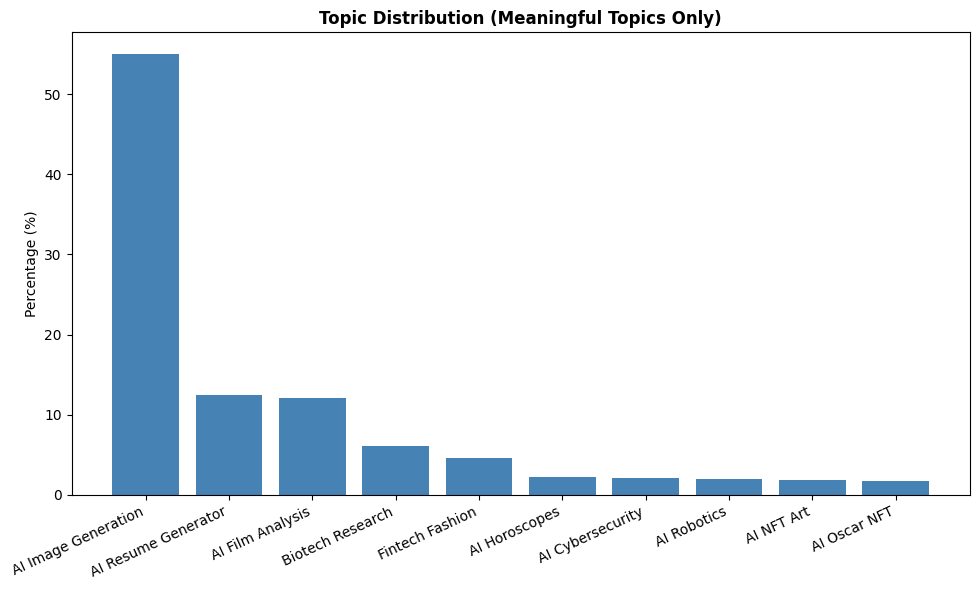

In [ ]:
# topic document distribution (meaningful topics only, excluding T0)
topic_meaningful = topic_info[topic_info['Topic'].isin(meaningful_ids)].copy()
topic_meaningful['Theme'] = topic_meaningful['Topic'].map(theme_labels)
topic_meaningful['Percentage'] = topic_meaningful['Count'] / topic_meaningful['Count'].sum() * 100
topic_meaningful_sorted = topic_meaningful.sort_values('Percentage', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(topic_meaningful_sorted['Theme'], topic_meaningful_sorted['Percentage'], color='steelblue')
plt.ylabel('Percentage (%)')
plt.title('Topic Distribution (Meaningful Topics Only)', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

Among the 10 meaningful topics, AI Image Generation dominates at around 55%, reflecting strong public interest in AI-generated visuals during this period. AI Resume Generator and AI Film Analysis follow at approximately 12% each, suggesting practical AI applications were also widely discussed. The remaining topics, including Biotech Research, Fintech Fashion, and AI Horoscopes, each account for less than 6%, indicating more niche conversations.

### 1.4 Before vs After GPT-4 Comparison

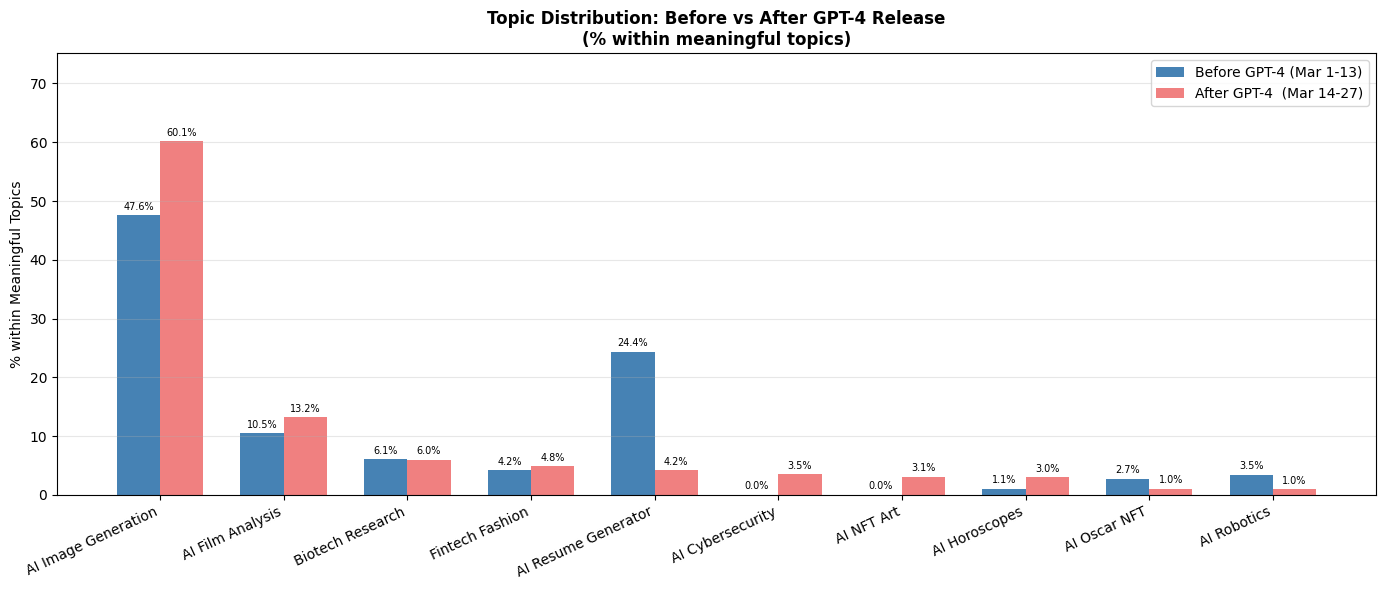

In [ ]:
# before vs after (meaningful topics only, excluding T0)
before_mask = data_df['date'] < '2023-03-14'
after_mask  = data_df['date'] >= '2023-03-14'

before_meaningful_total = data_df[before_mask]['topic'].isin(meaningful_ids).sum()
after_meaningful_total  = data_df[after_mask]['topic'].isin(meaningful_ids).sum()

before_pct = data_df[before_mask]['topic'].value_counts().reindex(meaningful_ids, fill_value=0) / before_meaningful_total * 100
after_pct  = data_df[after_mask]['topic'].value_counts().reindex(meaningful_ids, fill_value=0) / after_meaningful_total * 100

# sort by after_pct descending
sorted_ids  = after_pct.sort_values(ascending=False).index.tolist()
before_pct  = before_pct.reindex(sorted_ids)
after_pct   = after_pct.reindex(sorted_ids)
theme_names = [theme_labels[t] for t in sorted_ids]

x = np.arange(len(sorted_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, before_pct.values, width, label='Before GPT-4 (Mar 1-13)', color='steelblue')
bars2 = ax.bar(x + width/2, after_pct.values,  width, label='After GPT-4  (Mar 14-27)', color='lightcoral')

y_max = max(before_pct.max(), after_pct.max())
ax.set_ylim(0, y_max * 1.25)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_max * 0.01,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_max * 0.01,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(theme_names, rotation=25, ha='right')
ax.set_ylabel('% within Meaningful Topics')
ax.set_title('Topic Distribution: Before vs After GPT-4 Release\n(% within meaningful topics)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


After the GPT-4 release on March 14, topic shares within meaningful discussions shifted noticeably.                                                                   

**AI Image Generation** increased from 47.6% to 60.1% after GPT-4's release, suggesting that GPT-4's multimodal capabilities further fueled interest in AI-generated content. **AI Resume Generator** dropped sharply from 24.4% to 4.2%, indicating this topic was more prominent before the release, possibly reflecting pre-release anxiety about AI replacing jobs. **AI Cybersecurity** (0% → 3.5%) and** AI NFT Art **(0% → 3.1%) emerged only after GPT-4's release, pointing to new areas of discussion triggered by the launch.

At the same time, **AI Film Analysis** slightly increased from 10.5% to 13.2%, suggesting growing interest in AI applications in creative industries after GPT-4's launch. **Biotech Research** remained stable (6.1% → 6.0%), indicating consistent but unaffected discussion around AI in science. **Fintech Fashion** saw a minor increase (4.2% → 4.8%), while **AI Horoscopes** nearly tripled (1.1% → 3.0%), possibly reflecting growing curiosity in AI-generated entertainment content.

Overall, GPT-4's release shifted public conversation toward image generation and new AI applications. These shifts suggest that GPT-4 not only increased tweet volume but also redirected public attention toward creative and emerging AI applications.

# Module-2: Model Exploration (Supervised Learning)

## Part-1: Labels Preparation

### 1.1 Sampling by Time

In [ ]:
# sample 10,000 tweets by time
sample_df = (
    data_df.sort_values('date')
    .assign(time_bin=lambda x: pd.cut(x['date'], bins=10000, labels=False))
    .groupby('time_bin', group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
    .drop(columns='time_bin')
    [['date', 'content_clean']]
    .reset_index(drop=True)
)

# save to csv
from google.colab import drive
drive.mount('/content/drive')
sample_df.to_csv('/content/drive/MyDrive/sample_10k.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# read csv
sample_df = pd.read_csv('/content/drive/MyDrive/sample_10k.csv', parse_dates=['date'])
sample_df.head()

,date,content_clean
0,2023-03-01 00:00:02+00:00,do anything with chat gpt with prompts write w...
1,2023-03-01 00:03:53+00:00,there you have it chatgpt is biased
2,2023-03-01 00:09:23+00:00,according to a recent report from the informat...
3,2023-03-01 00:14:48+00:00,finally got it boys after doing this and a who...
4,2023-03-01 00:17:36+00:00,the whole discourse around chat gpt is fascina...


### 1.2 LLM Generate Labels


In [ ]:
!pip install anthropic openai -q

import anthropic
import pandas as pd
import time
from openai import OpenAI

In [ ]:
# configure API
CLAUDE_KEY   = "CLAUDE_KEY"
DEEPSEEK_KEY = "DEEPSEEK_KEY"
MINIMAX_KEY  = "MINIMAX_KEY"

claude_client   = anthropic.Anthropic(api_key=CLAUDE_KEY)
deepseek_client = OpenAI(api_key=DEEPSEEK_KEY, base_url="https://api.deepseek.com")
minimax_client  = OpenAI(api_key=MINIMAX_KEY,  base_url="https://api.minimax.chat/v1")

In [ ]:
# prompt
SYSTEM_PROMPT = """You are a sentiment classifier for tweets about ChatGPT and GPT-4.
Classify the sentiment as exactly one of: positive, negative, neutral.
Respond with ONLY the label, nothing else."""

def build_prompt(text):
    return f"Tweet: {text}\nSentiment:"

In [ ]:
# three LLM call functions

# claude
def label_claude(text):
    r = claude_client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=5,
        system=SYSTEM_PROMPT,
        messages=[{"role": "user", "content": build_prompt(text)}]
    )
    return r.content[0].text.strip().lower()

# deepseek
def label_deepseek(text):
    r = deepseek_client.chat.completions.create(
        model="deepseek-chat",
        max_tokens=5,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": build_prompt(text)}
        ]
    )
    return r.choices[0].message.content.strip().lower()

# minimax
def label_minimax(text):
    r = minimax_client.chat.completions.create(
        model="MiniMax-Text-01",
        max_tokens=5,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": build_prompt(text)}
        ]
    )
    return r.choices[0].message.content.strip().lower()

In [ ]:
# batch labeling

import os, json

SAVE_PATH = '/content/drive/MyDrive/labels_progress.json'
VALID_LABELS = {'positive', 'negative', 'neutral'}

# load progress if exists
if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH) as f:
        results = json.load(f)
else:
    results = {'claude': {}, 'deepseek': {}, 'minimax': {}}

def run_labeling(df, model_name, label_fn, results, save_every=100):
    done = results[model_name]
    for i, row in df.iterrows():
        if str(i) in done:
            continue
        try:
            label = label_fn(row['content_clean'])
            if label not in VALID_LABELS:
                label = 'neutral'
            done[str(i)] = label
        except Exception as e:
            print(f"[{model_name}] row {i} error: {e}")
            time.sleep(5)
            done[str(i)] = 'neutral'

        if i % save_every == 0:
            with open(SAVE_PATH, 'w') as f:
                json.dump(results, f)
            print(f"[{model_name}] {i}/{len(df)} done")

        time.sleep(0.1)  # rate limit

    with open(SAVE_PATH, 'w') as f:
        json.dump(results, f)
    print(f"[{model_name}] finished!")

# run one by one
run_labeling(sample_df, 'claude',    label_claude,    results)
run_labeling(sample_df, 'deepseek',  label_deepseek,  results)
run_labeling(sample_df, 'minimax',   label_minimax,   results)

[claude] finished!
[deepseek] finished!
[minimax] finished!


In [ ]:
sample_df['label_claude']   = [results['claude'][str(i)]   for i in sample_df.index]
sample_df['label_deepseek'] = [results['deepseek'][str(i)] for i in sample_df.index]
sample_df['label_minimax']  = [results['minimax'][str(i)]  for i in sample_df.index]

sample_df.to_csv('/content/drive/MyDrive/sample_10k_labeled.csv', index=False)

In [ ]:
sample_df = pd.read_csv('/content/drive/MyDrive/sample_10k_labeled.csv', parse_dates=['date'])
sample_df.head()

,date,content_clean,label_claude,label_deepseek,label_minimax
0,2023-03-01 00:00:02+00:00,do anything with chat gpt with prompts write w...,neutral,neutral,neutral
1,2023-03-01 00:03:53+00:00,there you have it chatgpt is biased,negative,negative,negative
2,2023-03-01 00:09:23+00:00,according to a recent report from the informat...,neutral,neutral,neutral
3,2023-03-01 00:14:48+00:00,finally got it boys after doing this and a who...,positive,positive,positive
4,2023-03-01 00:17:36+00:00,the whole discourse around chat gpt is fascina...,neutral,neutral,positive


### 1.3 LLM Comparison

In [ ]:
# cohen's kappa
# measures inter-annotator agreement between each pair of LLMs.
# higher Kappa = stronger agreement.
from sklearn.metrics import cohen_kappa_score

kappa_cd = cohen_kappa_score(sample_df['label_claude'], sample_df['label_deepseek'])
kappa_cm = cohen_kappa_score(sample_df['label_claude'], sample_df['label_minimax'])
kappa_dm = cohen_kappa_score(sample_df['label_deepseek'], sample_df['label_minimax'])

print(f"Claude vs DeepSeek:  {kappa_cd:.4f}")
print(f"Claude vs MiniMax:   {kappa_cm:.4f}")
print(f"DeepSeek vs MiniMax: {kappa_dm:.4f}")

Claude vs DeepSeek:  0.6686
Claude vs MiniMax:   0.7395
DeepSeek vs MiniMax: 0.6878


In [ ]:
# sentiment distribution
models = ['Claude', 'DeepSeek', 'MiniMax']
for col, name in zip(['label_claude', 'label_deepseek', 'label_minimax'], models):
    dist = sample_df[col].value_counts(normalize=True) * 100
    print(f"{name}: { {k: f'{v:.2f}%' for k, v in dist.to_dict().items()} }")

Claude: {'neutral': '43.15%', 'positive': '37.58%', 'negative': '19.27%'}
DeepSeek: {'neutral': '54.56%', 'positive': '33.90%', 'negative': '11.54%'}
MiniMax: {'positive': '41.78%', 'neutral': '40.94%', 'negative': '17.29%'}


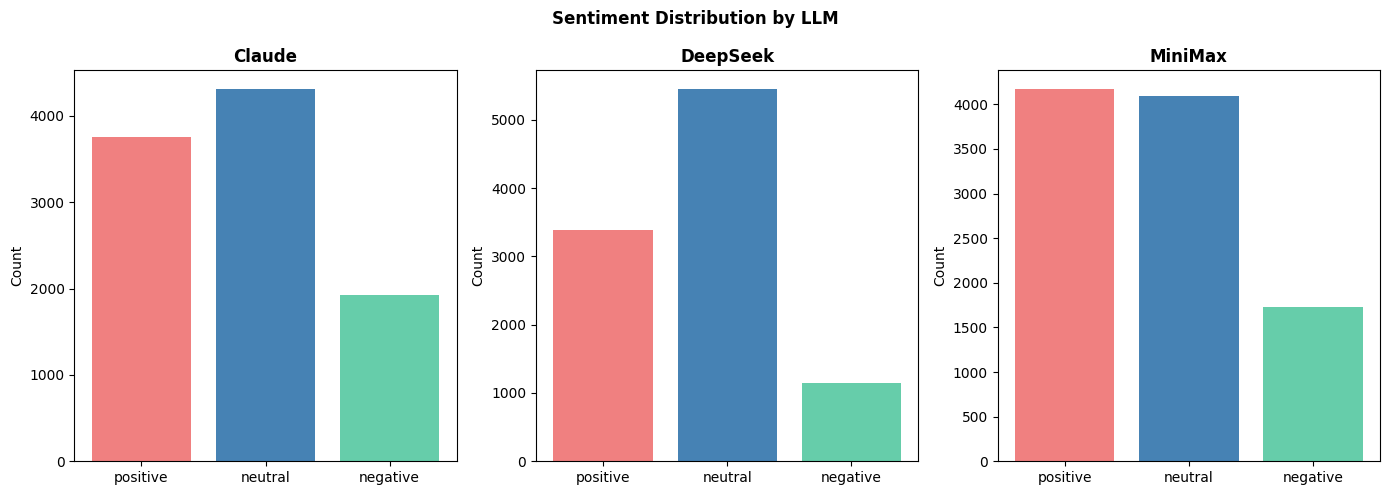

In [ ]:
# visualization
order = ['positive', 'neutral', 'negative']
colors_ordered = ['lightcoral', 'steelblue', 'mediumaquamarine']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, name in zip(axes, ['label_claude', 'label_deepseek', 'label_minimax'], models):
    counts = sample_df[col].value_counts().reindex(order)
    ax.bar(counts.index, counts.values, color=colors_ordered)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Sentiment Distribution by LLM', fontweight='bold')
plt.tight_layout()
plt.show()

**Model Selection**: Choose Claude

Reasons:

- Claude has the highest agreement with MiniMax (0.74), and it also sits in the "middle" (has relatively high agreement with both other models), indicating it is the most consistent annotator overall.
- Claude's distribution (43% neutral, 37% positive, 19% negative) is the most balanced and aligns best with typical Twitter sentiment patterns

### 1.4 Sentiment Visualization (Claude labels)

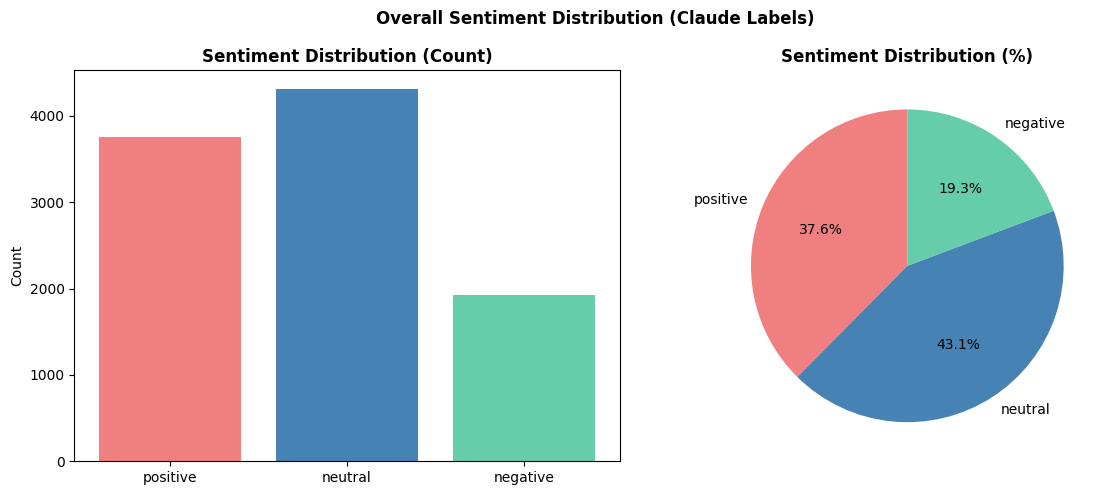

In [ ]:
#  overall sentiment distribution(by Claude)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ['positive', 'neutral', 'negative']
counts = sample_df['label_claude'].value_counts().reindex(order)
colors = {'positive': 'lightcoral', 'neutral': 'steelblue', 'negative': 'mediumaquamarine'}
color_list = [colors[c] for c in counts.index]

axes[0].bar(counts.index, counts.values, color=color_list)
axes[0].set_title('Sentiment Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=color_list, startangle=90)
axes[1].set_title('Sentiment Distribution (%)', fontweight='bold')

plt.suptitle('Overall Sentiment Distribution (Claude Labels)', fontweight='bold')
plt.tight_layout()
plt.show()

Among the 10,000 labeled tweets, neutral sentiment is the most common at 43.1%, followed by positive at 37.6% and negative at 19.3%. This suggests that public discussion around ChatGPT and GPT-4 is generally measured and informational, with more positive than negative reactions overall.

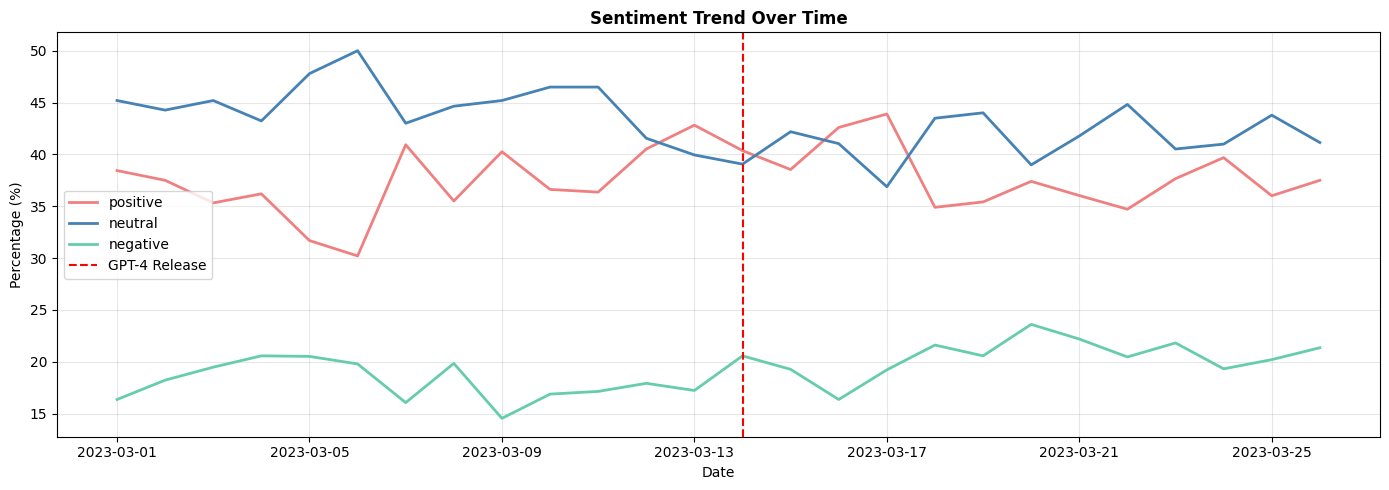

In [ ]:
# sentiment over time

sample_df['date'] = pd.to_datetime(sample_df['date']).dt.date

daily = sample_df.groupby(['date', 'label_claude']).size().unstack(fill_value=0)
daily_pct = daily.div(daily.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
for sentiment, color in colors.items():
    if sentiment in daily_pct.columns:
        ax.plot(daily_pct.index, daily_pct[sentiment], label=sentiment, color=color, lw=2)

ax.axvline(x=pd.to_datetime('2023-03-14').date(), color='red', linestyle='--', label='GPT-4 Release')
ax.set_title('Sentiment Trend Over Time', fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Around GPT-4's release on March 14, the three sentiment lines converged noticeably: positive sentiment rose to meet neutral, while neutral dropped to its lowest point. After the release, neutral sentiment recovered but remained slightly lower than pre-release levels, while negative sentiment showed a mild upward trend, peaking around March 21. This suggests that GPT-4's launch initially disrupted the stable sentiment pattern, generating more polarized reactions before gradually stabilizing.

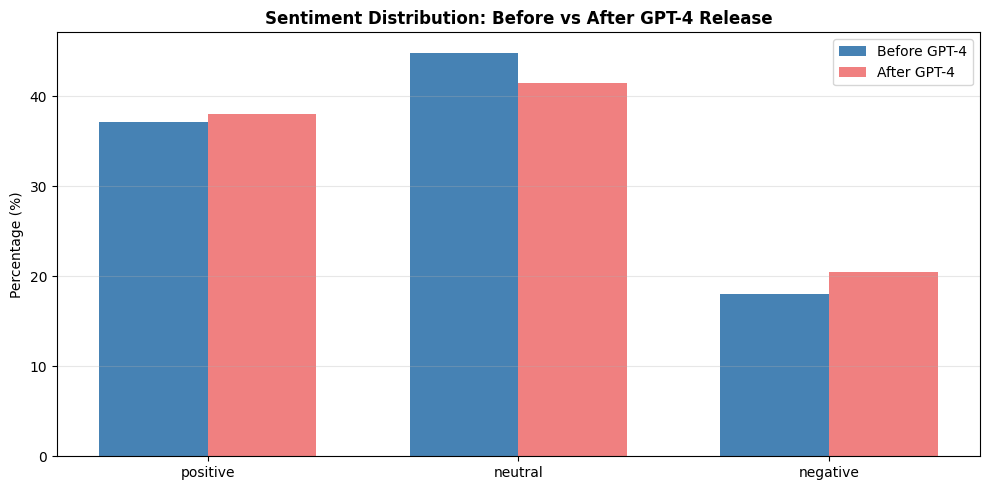

In [ ]:
# before vs after GPT-4

before = sample_df[sample_df['date'] < pd.to_datetime('2023-03-14').date()]
after  = sample_df[sample_df['date'] >= pd.to_datetime('2023-03-14').date()]

before_pct = before['label_claude'].value_counts(normalize=True) * 100
after_pct  = after['label_claude'].value_counts(normalize=True) * 100

sentiments = ['positive', 'neutral', 'negative']
x = range(len(sentiments))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], [before_pct.get(s, 0) for s in sentiments], width, label='Before GPT-4', color='steelblue')
ax.bar([i + width/2 for i in x], [after_pct.get(s, 0) for s in sentiments],  width, label='After GPT-4',  color='lightcoral')

ax.set_xticks(x)
ax.set_xticklabels(sentiments)
ax.set_ylabel('Percentage (%)')
ax.set_title('Sentiment Distribution: Before vs After GPT-4 Release', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Overall, following GPT-4's release, both positive and negative sentiment increased slightly (37.1% → 38.3% and 18.3% → 20.7% respectively), while neutral sentiment declined (44.9% → 41.5%). This suggests that although GPT-4 was generally well-received, its launch also sparked more criticism and concern among users.

### 1.5  Target Variable Distribution

Split data into train/val/test (70/10/20)

In [ ]:
# train/val/test split

from sklearn.model_selection import train_test_split

X = sample_df['content_clean']
y = sample_df['label_claude']

# first split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# second split: 70% train, 10% val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)# 0.125 x 0.8 = 0.1 → 10% of total

print(f"X_train: {len(X_train)}, X_val: {len(X_val)}, X_test: {len(X_test)}")

X_train: 6992, X_val: 999, X_test: 1998


In [ ]:
# tfidf(X_train)
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

important_words = {'ai', 'gpt', 'ml', 'dl', 'nlp', 'ui', 'ux'}
filtered_stopwords = [w for w in stopwords.words('english') if w not in important_words]

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=filtered_stopwords
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Train: {X_train_tfidf.shape}, Val: {X_val_tfidf.shape}, Test: {X_test_tfidf.shape}")

Train: (6992, 4153), Val: (999, 4153), Test: (1998, 4153)


In [ ]:
# get top20 features
feature_names = tfidf.get_feature_names_out()

def get_topn_features(X, feature_names, labels, sentiment, topn=20):
    """Return top-n mean TF-IDF features for a given sentiment class."""
    mask = labels == sentiment
    feature_ct = np.asarray(X[mask.values].mean(axis=0)).reshape(-1)
    feature_freq = [
        {'feature': feature_names[i], 'tfidf_score': feature_ct[i]}
        for i in np.argsort(feature_ct)[::-1][:topn]
    ]
    return pd.DataFrame(feature_freq)

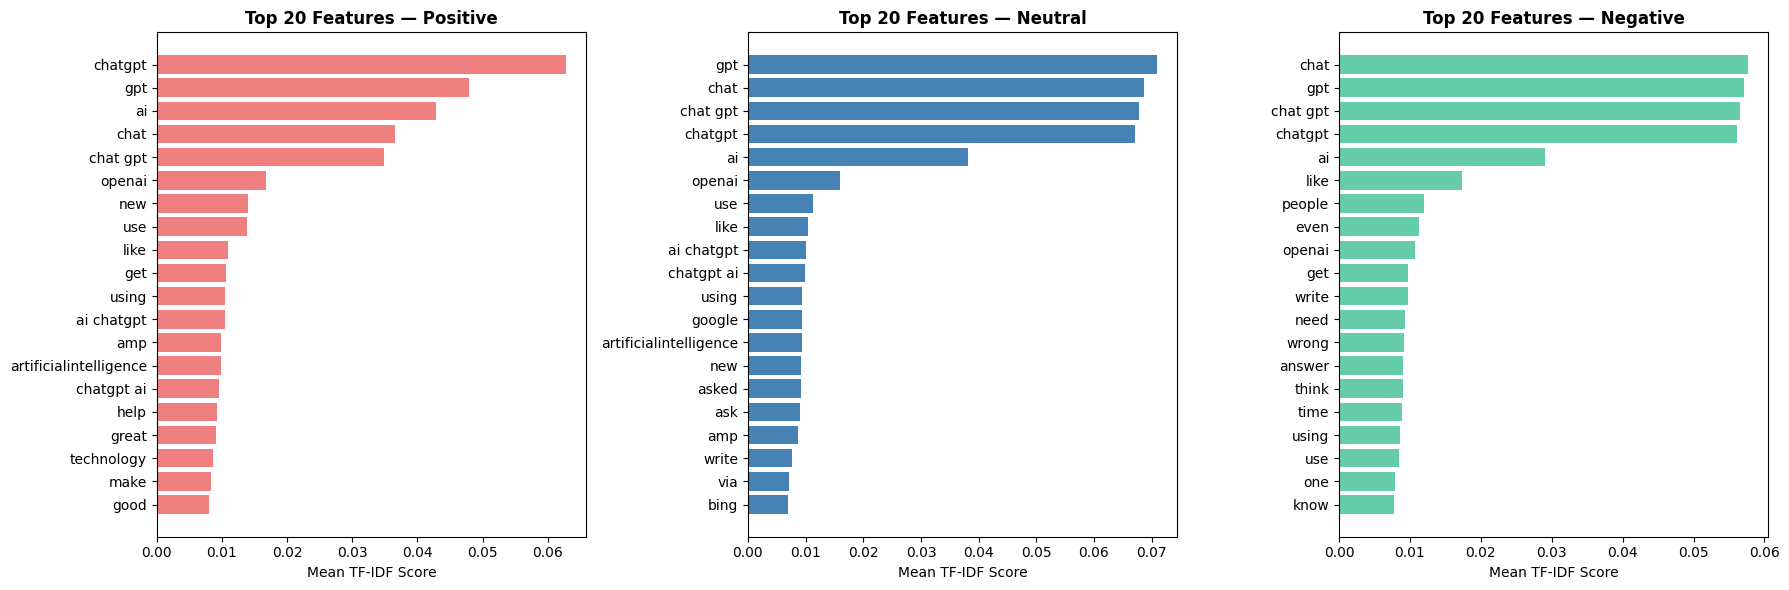

In [ ]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiments = ['positive', 'neutral', 'negative']
colors = ['lightcoral', 'steelblue', 'mediumaquamarine']

for ax, sentiment, color in zip(axes, sentiments, colors):
    df = get_topn_features(X_train_tfidf, feature_names, y_train, sentiment)
    ax.barh(df['feature'][::-1], df['tfidf_score'][::-1], color=color)
    ax.set_title(f'Top 20 Features — {sentiment.capitalize()}', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.show()

**Interpretation of Frequent Words by Sentiment**

All three sentiment classes share the same top features: "chatgpt", "gpt", "chat", "ai", confirming that the dataset is consistently focused on AI-related discussion regardless of sentiment.

However, the distinguishing features reveal clear differences. **Positive** tweets are associated with words like "help", "great", "good", and "new", reflecting enthusiasm and appreciation for ChatGPT's capabilities. **Neutral** tweets tend to emphasize informational or descriptive terms such as "google", "bing", "ask", and "write", suggesting a more factual discussion. **Negative** class shows the weakest feature differentiation, with most top words being generic terms such as "people", "even", "think", and "use" that appear across all sentiment classes. Only "wrong" and "need" carry a mildly negative connotation. This may be because negative sentiment in tweets tends to be expressed through context and tone rather than explicit negative vocabulary. It may also be attributed to the limited training size, with only 6,992 samples in X_train_tfidf, and the fact that negative sentiment has the smallest proportion of the three classes, resulting in fewer training examples for the model to learn from.

Overall, this suggests that while all users discuss the same technology, their framing differs significantly across sentiment classes.

In [ ]:
top_n = 200

class_top_words = {}
for sentiment in ['negative', 'neutral', 'positive']:
    mask = (y_train == sentiment).values
    feature_ct = np.asarray(X_train_tfidf[mask].mean(axis=0)).reshape(-1)
    top_idx = feature_ct.argsort()[-top_n:][::-1]
    class_top_words[sentiment.capitalize()] = set(feature_names[i] for i in top_idx)

all_shared = class_top_words['Negative'] & class_top_words['Neutral'] & class_top_words['Positive']
neg_unique  = class_top_words['Negative'] - class_top_words['Neutral'] - class_top_words['Positive']
neu_unique  = class_top_words['Neutral']  - class_top_words['Negative'] - class_top_words['Positive']
pos_unique  = class_top_words['Positive'] - class_top_words['Negative'] - class_top_words['Neutral']

print(f"Words shared across all 3 classes (top {top_n}): {len(all_shared)}")
print(f"Examples: {list(all_shared)[:10]}")

print(f"\nWords unique to Negative: {len(neg_unique)}")
print(f"Examples: {list(neg_unique)[:10]}")

print(f"Words unique to Neutral: {len(neu_unique)}")
print(f"Examples: {list(neu_unique)[:10]}")

print(f"Words unique to Positive: {len(pos_unique)}")
print(f"Examples: {list(pos_unique)[:10]}")

Words shared across all 3 classes (top 200): 86
Examples: ['data', 'chat', 'could', 'ask', 'questions', 'know', 'openai', 'one', 'see', 'chatgpt openai']

Words unique to Negative: 74
Examples: ['hype', 'important', 'making', 'since', 'gone', 'woke', 'someone', 'exam', 'feel', 'fake']
Words unique to Neutral: 45
Examples: ['ai gpt', 'name', 'yet', 'ai chat', 'sale', 'seo', 'hey', 'open', 'tweet', 'sure']
Words unique to Positive: 57
Examples: ['creating', 'project', 'current chatgpt', 'fun', 'youtube', 'explore', 'blockchain', 'ideas', 'week', 'capabilities']


**Interpretation of Shared and Class-Specific Vocabulary**

With 86 shared words (e.g., data, openai, chatgpt, questions), the conversation across all sentiment groups remains anchored in the product's basic functions. These terms represent the "objective baseline" of the discussion, showing that users are primarily focused on the core utility of the LLM regardless of their emotional stance.

However, the 74 unique negative words (e.g., hype, fake, woke, exam) reveal two main clusters of concern:
- Authenticity: Users question whether GPT-4 is over-hyped or prone to generating misleading information.
- Societal Impact: Words like woke and exam reflect broader anxieties around AI bias and academic integrity.

The 57 unique positive words (e.g., creating, explore, capabilities, ideas, fun) reflect users' excitement about GPT-4's potential, showing enthusiasm for exploring new workflows and creative use cases.


## Part-2: Linear Model

### 2.1 Logistic Regression (Base Model)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

print(f"Logistic Regression (Base) — Val Accuracy: {float('%.3f' % lr.score(X_val_tfidf, y_val))}")
print(classification_report(y_val, lr.predict(X_val_tfidf)))

Logistic Regression (Base) — Val Accuracy: 0.61
              precision    recall  f1-score   support

    negative       0.66      0.33      0.44       193
     neutral       0.58      0.70      0.64       431
    positive       0.63      0.65      0.64       375

    accuracy                           0.61       999
   macro avg       0.63      0.56      0.57       999
weighted avg       0.62      0.61      0.60       999



### 2.2 Logistic Regression (Hyperparameter Tuning)

In [ ]:
# Ridge + Lasso tuning (evaluation with different metrics)
results_lr = []

for C in [0.01, 0.1, 1, 10, 100]:
    for penalty in ['l1', 'l2']:
        for class_weight in [None, 'balanced']:
            model = LogisticRegression(C=C, penalty=penalty, solver='saga',
                                       class_weight=class_weight, max_iter=1000, random_state=42)
            model.fit(X_train_tfidf, y_train)
            score = model.score(X_val_tfidf, y_val)
            results_lr.append({'C': C, 'penalty': penalty,
                                'class_weight': class_weight,
                                'val_accuracy': float('%.3f' % score)})

results_lr_df = pd.DataFrame(results_lr).sort_values('val_accuracy', ascending=False)
results_lr_df.head(10)

,C,penalty,class_weight,val_accuracy
10,1.0,l2,None,0.610
15,10.0,l2,balanced,0.602
14,10.0,l2,None,0.600
9,1.0,l1,balanced,0.594
11,1.0,l2,balanced,0.594
8,1.0,l1,None,0.591
13,10.0,l1,balanced,0.580
7,0.1,l2,balanced,0.572
12,10.0,l1,None,0.569
19,100.0,l2,balanced,0.568


### 2.3 Logistic Regression (Best Model)

In [ ]:
# best logistic regression model
best_lr = LogisticRegression(C=1.0, penalty='l2', solver='saga',
                              class_weight=None, max_iter=1000, random_state=42)
best_lr.fit(X_train_tfidf, y_train)

print(f"Best Logistic Regression — Val Accuracy: {float('%.3f' % best_lr.score(X_val_tfidf, y_val))}")
print(classification_report(y_val, best_lr.predict(X_val_tfidf)))

Best Logistic Regression — Val Accuracy: 0.61
              precision    recall  f1-score   support

    negative       0.65      0.33      0.44       193
     neutral       0.58      0.70      0.64       431
    positive       0.63      0.65      0.64       375

    accuracy                           0.61       999
   macro avg       0.62      0.56      0.57       999
weighted avg       0.62      0.61      0.60       999



In [ ]:
# extract top predictive features per class
for i, cls in enumerate(best_lr.classes_):
    feature_to_coef = {word: float('%.3f' % coef)
                       for word, coef in zip(feature_names, best_lr.coef_[i])}
    top_pos = sorted(feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\nTop features for [{cls}]: {top_pos}")


Top features for [negative]: [('wrong', 2.383), ('malware', 1.864), ('even', 1.79), ('woke', 1.727), ('fake', 1.673), ('job', 1.652), ('bug', 1.627), ('nothing', 1.62), ('people', 1.618), ('upsc', 1.602)]

Top features for [neutral]: [('longest', 1.403), ('meta', 1.202), ('sale', 1.187), ('article', 1.075), ('chatgpt generativeai', 1.034), ('asking', 1.022), ('sure', 0.993), ('reply', 0.989), ('earth', 0.959), ('vs', 0.946)]

Top features for [positive]: [('amazing', 2.631), ('great', 2.314), ('love', 2.227), ('exciting', 2.185), ('excited', 1.906), ('help', 1.69), ('powered', 1.653), ('best', 1.647), ('explore', 1.628), ('thanks', 1.619)]


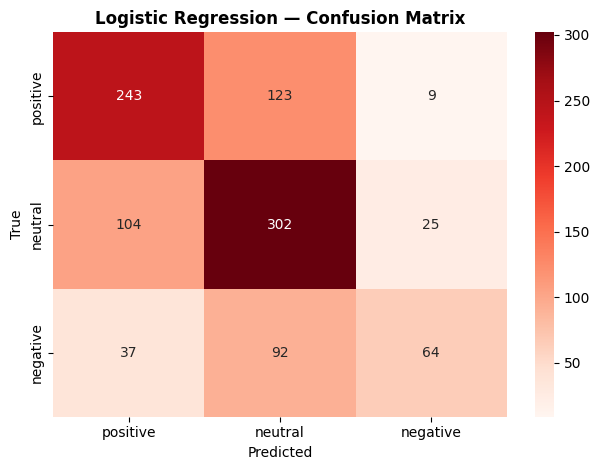

In [ ]:
# confusion matrix
cm_lr = confusion_matrix(y_val, best_lr.predict(X_val_tfidf),
                      labels=['positive', 'neutral', 'negative'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

**Explanation:**

- **The base Logistic Regression model** achieves a validation accuracy of 0.61, with notably asymmetric performance across classes. Neutral and positive sentiments achieve F1 scores of 0.64, benefiting from larger training support (431 and 375 samples respectively). Negative sentiment, however, yields a markedly lower F1 of 0.44, driven primarily by poor recall (0.33), indicating that the model systematically fails to identify negative tweets, classifying the majority as neutral.

- **Hyperparameter Tuning:** A grid search over C ∈ {0.01, 0.1, 1, 10, 100}, penalty types (L1/L2), and class weighting strategies yields a best configuration of C=1.0, L2 regularization, and no class weighting, with a validation accuracy of 0.610. The negligible improvement over the base model suggests that the default parameterization was already well-suited to this dataset, and that performance limitations stem from data characteristics rather than suboptimal regularization.

- **Logistic Regression Model Performance Interpretation:** The top coefficient features are semantically coherent and directionally sensible. Positive sentiment is driven by affective terms such as "amazing" (2.631), "great" (2.314), "love" (2.227), and "exciting" (2.185), reflecting genuine enthusiasm. Negative sentiment is associated with "wrong" (2.383), "malware" (1.864), "woke" (1.727), and "fake" (1.673), capturing both factual errors and sociopolitical critique. Neutral features such as "longest", "meta", and "article" reflect purely descriptive language. These coefficients validate the model's internal logic and confirm that it has learned meaningful sentiment-word associations.

- **The confusion matrix** exposes the model's core limitation: while neutral tweets are classified with reasonable accuracy (302/431 correct), negative tweets are severely underperformed: only 64 of 193 negative instances are correctly identified, with 92 misclassified as neutral. This systematic confusion between negative and neutral reflects a fundamental challenge: negative sentiment in tweets is frequently conveyed through irony, understatement, or contextual implication rather than explicit negative vocabulary, making it difficult for a TF-IDF based Logistic Regression model to reliably discriminate between the two classes. This finding motivates the exploration of more expressive models in future work.

## Part-3: Tree Model

### 3.1 Random Forest (Base Model)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_tfidf, y_train)

print(f"Random Forest (Base) — Val Accuracy: {float('%.3f' % rf.score(X_val_tfidf, y_val))}")
print(classification_report(y_val, rf.predict(X_val_tfidf)))

Random Forest (Base) — Val Accuracy: 0.602
              precision    recall  f1-score   support

    negative       0.62      0.21      0.31       193
     neutral       0.58      0.77      0.66       431
    positive       0.64      0.61      0.62       375

    accuracy                           0.60       999
   macro avg       0.61      0.53      0.53       999
weighted avg       0.61      0.60      0.58       999



### 3.2 Random Forest (Hyperparameter Tuning)

In [ ]:
# evaluation with different metrics
results_rf = []

for n_estimators in [50, 100, 150, 200, 250, 300]:
    for max_depth in [10, 15, 20, 25, 30, None]:
        for min_samples_leaf in [1, 3, 5, 7, 9]:
          for max_features in ['sqrt', 'log2']:
            model = RandomForestClassifier(criterion='entropy',
                                           n_estimators=n_estimators,
                                           max_features=max_features,
                                           max_depth=max_depth,
                                           min_samples_leaf=min_samples_leaf,
                                           random_state=42)
            model.fit(X_train_tfidf, y_train)
            score = model.score(X_val_tfidf, y_val)
            results_rf.append({'n_estimators': n_estimators,
                                'max_depth': max_depth,
                                'min_samples_leaf': min_samples_leaf,
                                'max_features': max_features,
                                'val_accuracy': float('%.3f' % score)})

results_rf_df = pd.DataFrame(results_rf).sort_values('val_accuracy', ascending=False)
results_rf_df.head(10)

,n_estimators,max_depth,min_samples_leaf,max_features,val_accuracy
351,300,NaN,1,log2,0.608
291,250,NaN,1,log2,0.604
171,150,NaN,1,log2,0.601
170,150,NaN,1,sqrt,0.601
112,100,NaN,3,sqrt,0.601
231,200,NaN,1,log2,0.600
172,150,NaN,3,sqrt,0.598
350,300,NaN,1,sqrt,0.596
173,150,NaN,3,log2,0.594
293,250,NaN,3,log2,0.594


### 3.3 Random Forest (Best Model)

In [ ]:
# best random forest model
best_rf = RandomForestClassifier(criterion='entropy', n_estimators=300,
                                  max_features='log2', max_depth=None,
                                  min_samples_leaf=1, random_state=42)
best_rf.fit(X_train_tfidf, y_train)

print(f"Best Random Forest — Val Accuracy: {float('%.3f' % best_rf.score(X_val_tfidf, y_val))}")
print(classification_report(y_val, best_rf.predict(X_val_tfidf)))

Best Random Forest — Val Accuracy: 0.608
              precision    recall  f1-score   support

    negative       0.66      0.22      0.33       193
     neutral       0.57      0.81      0.67       431
    positive       0.67      0.58      0.62       375

    accuracy                           0.61       999
   macro avg       0.63      0.53      0.54       999
weighted avg       0.62      0.61      0.58       999



In [ ]:
# extract top features
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).round(4).head(20)
feature_importance_df

,feature,importance
639,chatgpt,0.0175
1733,gpt,0.0135
622,chat,0.0118
626,chat gpt,0.0115
71,ai,0.0087
2725,openai,0.0035
2297,like,0.0034
1851,great,0.0033
3886,use,0.0031
1399,even,0.0031


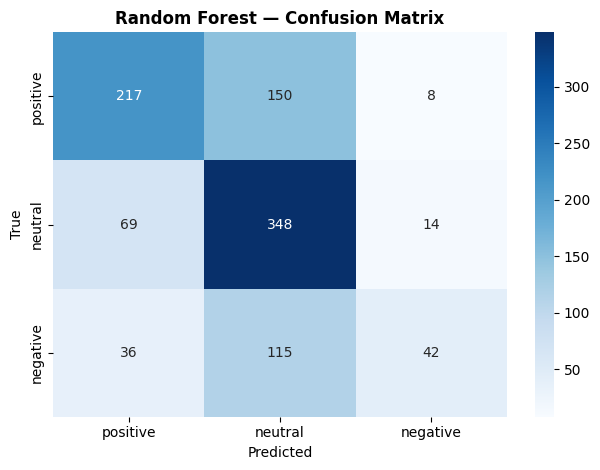

In [ ]:
cm_rf = confusion_matrix(y_val, best_rf.predict(X_val_tfidf),
                         labels=['positive', 'neutral', 'negative'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

**Explanation:**

- **The base Random Forest** achieves a validation accuracy of 0.602, comparable to Logistic Regression (0.61). However, the class-level performance reveals a more severe imbalance: negative sentiment yields an F1 of only 0.31, with recall dropping to 0.21, meaning the model correctly identifies fewer than one in four negative tweets. This is even weaker than Logistic Regression on the negative class.

- **Hyperparameter Tuning:** An extensive grid search over n_estimators ∈ {50, 100, 150, 200, 250, 300}, max_depth ∈ {10, 15, 20, 25, 30, None}, min_samples_leaf ∈ {1, 3, 5, 7, 9}, and max_features ∈ {sqrt, log2} yields a best configuration of n_estimators=300, max_depth=None, min_samples_leaf=1, max_features=log2, with a validation accuracy of 0.608.

- **Random Forest Model Performance Interpretation:** The best Random Forest improves slightly to 0.608 validation accuracy. Unlike Logistic Regression's class-specific coefficients, Random Forest feature importances are global and class-agnostic, reflecting overall discriminative power rather than directional sentiment contribution. Unsurprisingly, topic-defining terms such as "chatgpt" (0.0175), "gpt" (0.0135), "chat" (0.0118), and "ai" (0.0087) dominate, confirming that the model relies heavily on subject-matter keywords. The low absolute importance values across all features suggest that predictive signal is diffusely distributed across the vocabulary, with no single term being strongly decisive.

- **The confusion matrix** reveals a pattern consistent with the base model: neutral tweets are classified most accurately (348/431), while negative tweets remain severely underperformed — only 42 of 193 negative instances are correctly identified, with 115 misclassified as neutral. Compared to Logistic Regression (64 correct negatives), Random Forest performs markedly worse on the negative class despite a similar overall accuracy.

## Part-4: Final Model

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

print("Final Evaluation on Testing Set")
print(f"\nLogistic Regression — Test Accuracy: {float('%.3f' % best_lr.score(X_test_tfidf, y_test))} | Macro-F1: {f1_score(y_test, best_lr.predict(X_test_tfidf), average='macro'):.3f}")
print(f"Random Forest      — Test Accuracy: {float('%.3f' % best_rf.score(X_test_tfidf, y_test))} | Macro-F1: {f1_score(y_test, best_rf.predict(X_test_tfidf), average='macro'):.3f}")

Final Evaluation on Test Set

Logistic Regression — Test Accuracy: 0.612 | Macro-F1: 0.564
Random Forest      — Test Accuracy: 0.596 | Macro-F1: 0.527


Logistic Regression outperforms Random Forest on all metrics(test accuracy, Macro-F1 and recall) , so choose Logistic Regression as my final model.


In [ ]:
# exclude the 10k sample
remaining_df = data_df[~data_df.index.isin(sample_df.index)].reset_index(drop=True)

# transform the remainning data
X_remaining_tfidf = tfidf.transform(remaining_df['content_clean'])

# predict on remaining data
remaining_df['sentiment'] = best_lr.predict(X_remaining_tfidf)

print(remaining_df['sentiment'].value_counts())

sentiment
neutral     80490
positive    59305
negative    14764
Name: count, dtype: int64


In [ ]:
# merge sample_df with remaining_df

sample_df['sentiment'] = sample_df['label_claude']

all_df = pd.concat([
    sample_df[['date', 'content_clean', 'sentiment']],
    remaining_df[['date', 'content_clean', 'sentiment']]
], ignore_index=True).sort_values('date').reset_index(drop=True)

all_df.to_csv('/content/drive/MyDrive/all_labeled.csv', index=False)
print(f"Total: {len(all_df)} tweets")

Total: 164548 tweets


**Explanation:**

On the held-out test set, Logistic Regression outperforms Random Forest across both metrics: Test Accuracy (0.612 vs 0.596) and Macro-F1 (0.564 vs 0.527). Logistic Regression is therefore selected as the final model.

Then the best Logistic Regression model is applied to the remaining tweets (excluding the 10k labeled sample), producing the following distribution: neutral (80,490, 52.1%), positive (59,305, 38.4%), and negative (14,764, 9.6%). Notably, the proportion of negative tweets (9.6%) is considerably lower than in the labeled sample (19.3%), which is likely attributable to the model's poor predictive performance on the negative class — as evidenced by its low recall (0.33) on the validation set, the model tends to misclassify negative tweets as neutral, resulting in a systematic underprediction of negative sentiment in the full dataset.

# Module-3: Result Analysis

## Part-1: Error Analysis

In [ ]:
import textwrap

test_df = X_test.reset_index(drop=True).to_frame(name='content_clean')
test_df['true_sentiment'] = y_test.reset_index(drop=True).values
test_df['pred_sentiment'] = best_lr.predict(X_test_tfidf)

# define misclassification flags
test_df['misclassified_negative'] = (test_df['true_sentiment'] == 'negative') & (test_df['pred_sentiment'] != 'negative')
test_df['misclassified_positive'] = (test_df['true_sentiment'] == 'positive') & (test_df['pred_sentiment'] != 'positive')
test_df['misclassified_neutral']  = (test_df['true_sentiment'] == 'neutral')  & (test_df['pred_sentiment'] != 'neutral')

In [ ]:
RED   = '\033[1;31m'  # positive = red
GREEN = '\033[1;32m'  # neutral = green
BLUE  = '\033[1;34m'  # negative = blue
END   = '\033[0m'

def interpretation(text, vectorizer, model, sentiment_idx, wrap_length=250, use_color=True):
    """Annotate each word with its LR coefficient; red=positive, green=neutral, blue=negative."""
    analysis = []
    for wd in text.split():
        if wd in vectorizer.vocabulary_:
            wd_id = vectorizer.vocabulary_[wd]
            coef  = model.coef_[sentiment_idx][wd_id]
            to_append = wd
            if use_color and coef > 0:
                to_append = RED   + to_append + END
            elif use_color and coef < 0:
                to_append = BLUE  + to_append + END
            else:
                to_append = GREEN + to_append + END
            to_append = to_append + '(' + ('%.3f' % coef) + ')'
            analysis.append(to_append)
        else:
            analysis.append(wd)
    print(textwrap.fill(' '.join(analysis), width=wrap_length))

class_idx = {cls: i for i, cls in enumerate(best_lr.classes_)}
print(class_idx)

{'negative': 0, 'neutral': 1, 'positive': 2}


In [ ]:
# show misclassified negative tweets
test_df[test_df.misclassified_negative].head()[['content_clean', 'true_sentiment', 'pred_sentiment']]

,content_clean,true_sentiment,pred_sentiment
7,and my impression is that us regulators do not...,negative,neutral
14,the growing dependency on artificialintelligen...,negative,neutral
30,nooooo the chat gpt won t do it for me either,negative,neutral
34,if i was a big account id ask my followers to ...,negative,neutral
48,chatgpt is down what we know,negative,neutral


In [ ]:
example1 = test_df[test_df.misclassified_negative].iloc[4]
print(f"True label: {example1['true_sentiment']}, Predicted: {example1['pred_sentiment']}")
interpretation(example1['content_clean'], tfidf, best_lr, sentiment_idx=class_idx['negative'])

True label: negative, Predicted: neutral
chatgpt(-0.211) is down what we know(0.098)


In [ ]:
# show misclassified positive tweets
test_df[test_df.misclassified_positive].head()[['content_clean', 'true_sentiment', 'pred_sentiment']]

,content_clean,true_sentiment,pred_sentiment
4,check out my latest article the game changer h...,positive,neutral
8,chat gpt who s hype,positive,neutral
10,not bad chatgpt not bad at all,positive,negative
11,i asked chat gpt to come up with a band name f...,positive,neutral
12,yessssssir chatgpt,positive,neutral


In [ ]:
example2 = test_df[test_df.misclassified_positive].iloc[2]
print(f"True label: {example2['true_sentiment']}, Predicted: {example2['pred_sentiment']}")
interpretation(example2['content_clean'], tfidf, best_lr, sentiment_idx=class_idx['positive'])

True label: positive, Predicted: negative
not bad(-0.295) chatgpt(-0.659) not bad(-0.295) at all


- **Misclassified Negative Tweets:** All five misclassified negative examples are predicted as neutral, revealing a consistent failure mode. Tweets such as "and my impression is that us regulators do not..." and "the growing dependency on artificialintelligen..." express concern or criticism through contextual implication rather than explicit negative vocabulary. The coefficient interpretation for example1 ("chatgpt is down what we know") illustrates this precisely: "chatgpt" carries a negative coefficient (−0.211), but the signal is too weak to override the neutral prediction, partially cancelled by "know" (+0.098).  This reflects the model's inability to capture implicit negativity, which treats text as a bag of independent tokens without any understanding of tone, context, or pragmatic meaning.

- **Misclassified Positive Tweets:** The misclassified positive examples expose a second critical failure mode: negation. "not bad chatgpt not bad at all" is genuinely positive in intent, yet the model predicts negative. The interpretation confirms why: "bad" carries a strong negative coefficient (−0.295), and the model cannot recognize that "not bad" inverts its polarity. Similarly, "chat gpt who s hype" and "yesssssir chatgpt" are clearly positive through informal expression and enthusiasm, yet are predicted as neutral because these informal markers carry no significant TF-IDF weight. This reveals that the model systematically fails on colloquial and negation-based positivity(but both of which are extremely prevalent in Twitter discourse, that's partially why model performance is relatively poor here).


**Possible Improvements**

- **Richer text representations:** Replacing TF-IDF with contextual embeddings from pre-trained transformer models (e.g., BERTweet, RoBERTa fine-tuned on Twitter data) would allow the model to capture negation, sarcasm, and implicit sentiment that surface-level features cannot encode.
- **Longer context:** The core bottleneck is tweet length or the data itself: after preprocessing, tweets average only 14.20 words in length, providing limited linguistic context for sentiment classification. Short-form social media text is inherently ambiguous: a single tweet rarely contains sufficient signal for reliable sentiment inference, particularly for subtle or implicit expressions. If future work could incorporate richer contextual representations may yield more meaningful gains.
- **Handling class imbalance:** The negative class is consistently underperformed due to its smaller training support. Solution: Using LLM to generate more negative texts/content.
- **Label quality:** The ground truth labels are generated by Claude, not real lables, and this may limit model accuracy. Solution: human validation of a subset of labels.



## Part-2: Sentiment by Time

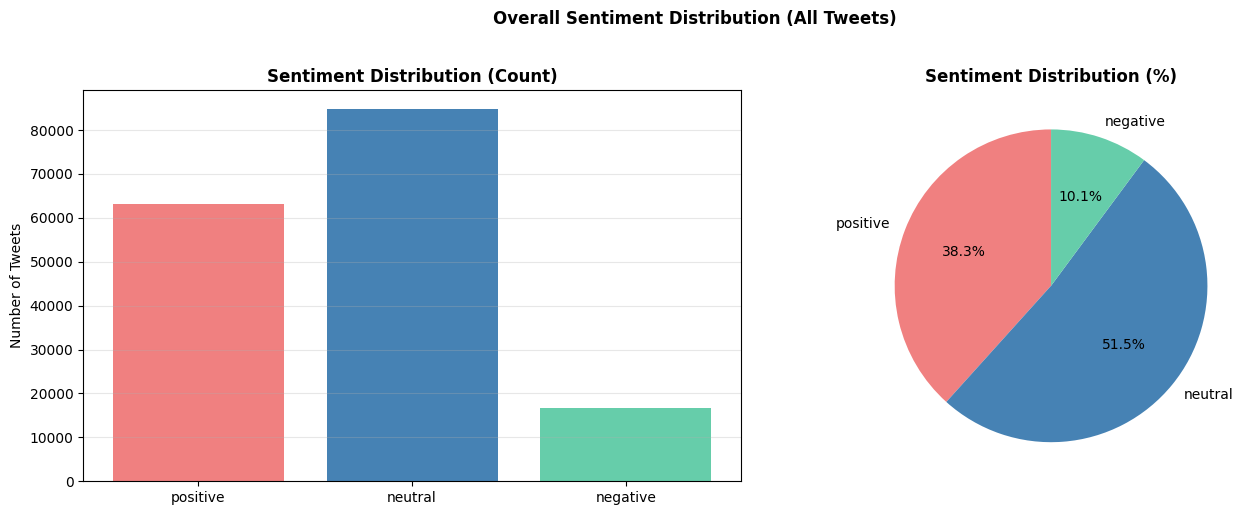

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order  = ['positive', 'neutral', 'negative']
colors = ['lightcoral', 'steelblue', 'mediumaquamarine']

# bar chart
counts = all_df['sentiment'].value_counts().reindex(order)
axes[0].bar(order, counts.values, color=colors)
axes[0].set_title('Sentiment Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
axes[0].grid(axis='y', alpha=0.3)

# pie chart
axes[1].pie(counts.values, labels=order, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Sentiment Distribution (%)', fontweight='bold')

plt.suptitle('Overall Sentiment Distribution (All Tweets)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Across all 164,548 tweets, neutral sentiment is the most prevalent at 51.5%, followed by positive at 38.3% and negative at 10.1%.

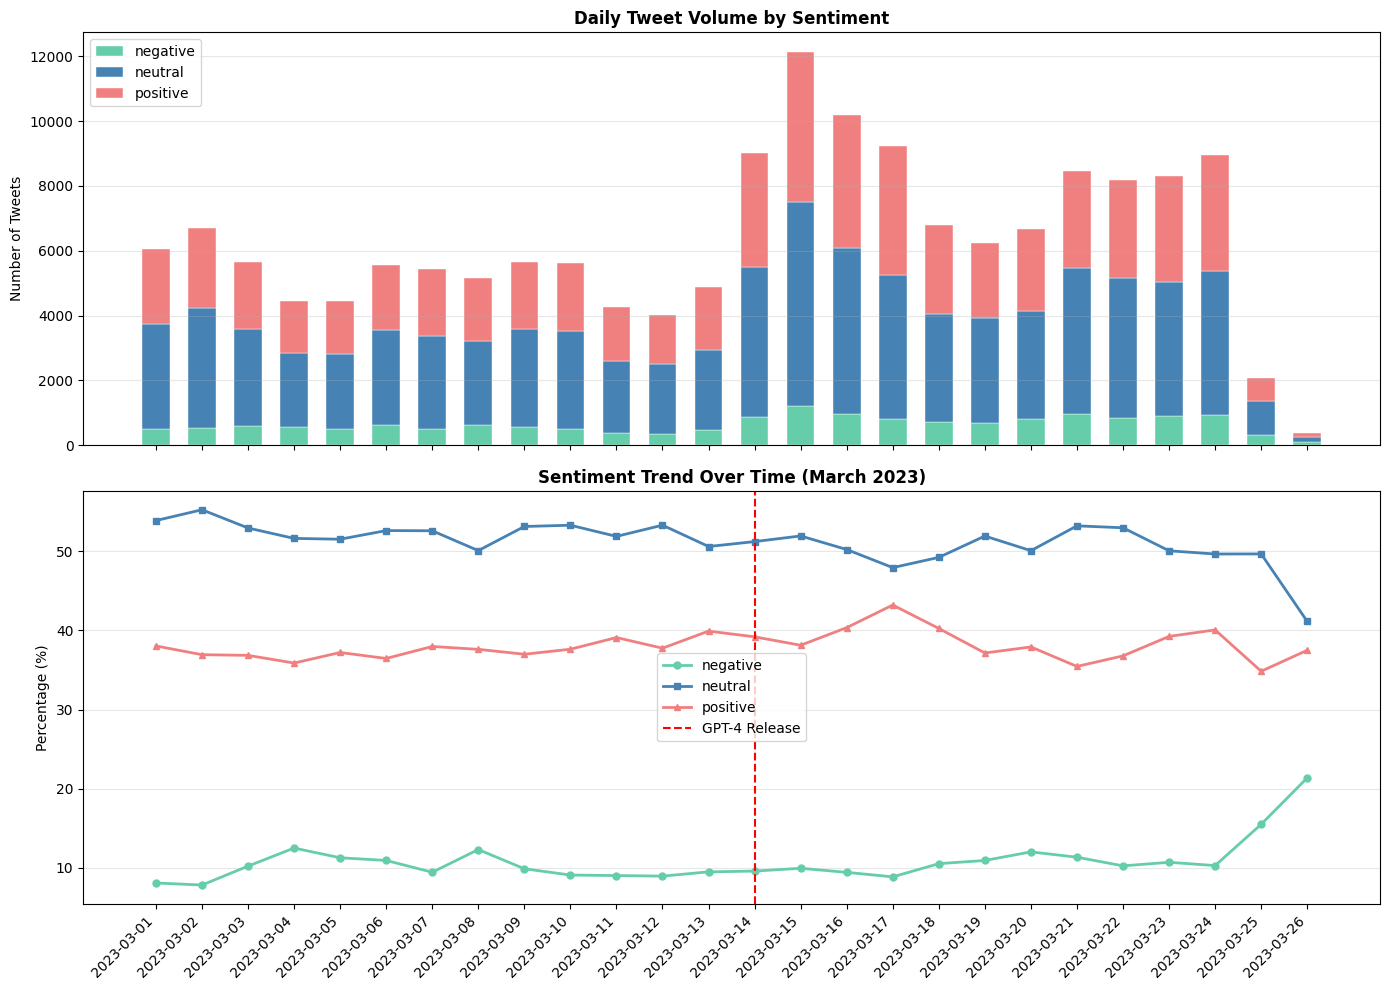

In [ ]:
all_df['date'] = pd.to_datetime(all_df['date'])
all_df['day'] = all_df['date'].dt.to_period('D')

daily = (
    all_df
    .groupby(['day', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['negative', 'neutral', 'positive'], fill_value=0)
)

daily_pct = daily.div(daily.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

x_labels = daily.index.astype(str)
x = np.arange(len(x_labels))
w = 0.6

# stacked bar
bottom = np.zeros(len(x))
for sent, color in [('negative', 'mediumaquamarine'), ('neutral', 'steelblue'), ('positive', 'lightcoral')]:
    vals = daily[sent].values
    axes[0].bar(x, vals, w, bottom=bottom, label=sent, color=color, edgecolor='white', linewidth=0.3)
    bottom += vals

axes[0].set_ylabel('Number of Tweets')
axes[0].set_title('Daily Tweet Volume by Sentiment', fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# line chart
gpt4_idx = list(x_labels).index('2023-03-14')
for sent, color, marker in [('negative', 'mediumaquamarine', 'o'),
                              ('neutral',  'steelblue',        's'),
                              ('positive', 'lightcoral',       '^')]:
    axes[1].plot(x, daily_pct[sent].values, marker=marker, color=color,
                 label=sent, linewidth=2, markersize=5)

axes[1].axvline(x=gpt4_idx, color='red', linestyle='--', linewidth=1.5, label='GPT-4 Release')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Sentiment Trend Over Time (March 2023)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The stacked bar chart shows a clear spike in total tweet volume immediately after GPT-4's release on March 14, peaking on March 15. The percentage line chart reveals that sentiment proportions remained relatively stable throughout the period, with neutral consistently dominating.

However, a subtle shift is visible around the release date, where positive sentiment briefly rises while neutral dips, before both return toward their baseline levels in the following days.

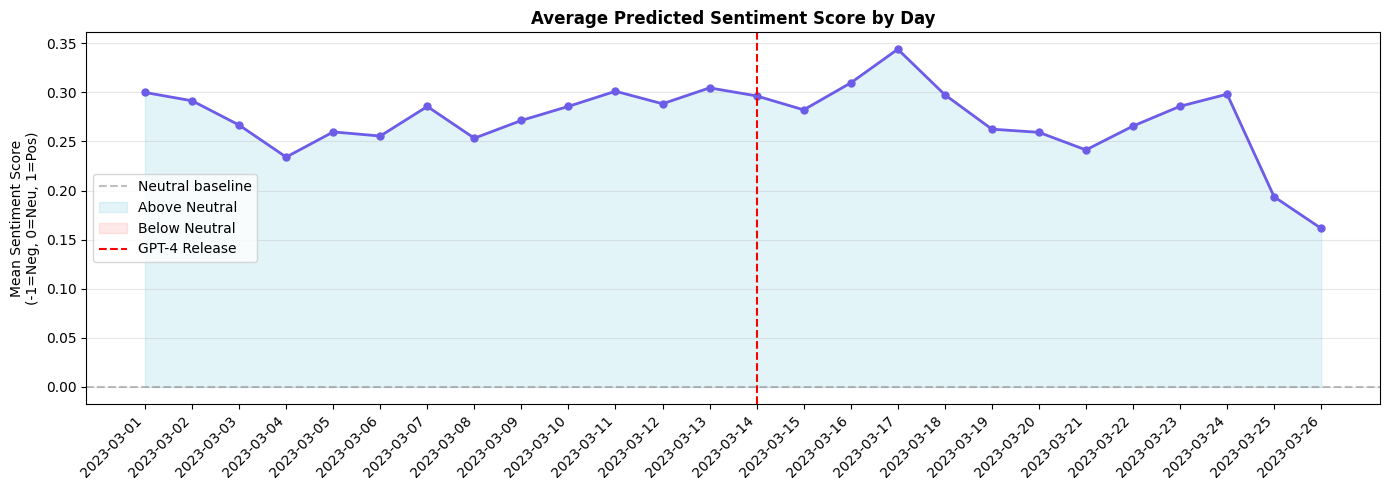

In [ ]:
# map sentiment to numeric score: negative=-1, neutral=0, positive=1
score_map = {'negative': -1, 'neutral': 0, 'positive': 1}
all_df['sentiment_score'] = all_df['sentiment'].map(score_map)

daily_avg = all_df.groupby('day')['sentiment_score'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(daily_avg))

ax.plot(x, daily_avg.values, marker='o', color='#6c5ce7', linewidth=2, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Neutral baseline')
ax.fill_between(x, 0, daily_avg.values,
                where=(daily_avg.values >= 0), alpha=0.15, color='#45b7d1', label='Above Neutral')
ax.fill_between(x, 0, daily_avg.values,
                where=(daily_avg.values < 0),  alpha=0.15, color='#ff6b6b', label='Below Neutral')

gpt4_idx = list(daily_avg.index.astype(str)).index('2023-03-14')
ax.axvline(x=gpt4_idx, color='red', linestyle='--', linewidth=1.5, label='GPT-4 Release')

ax.set_xticks(x)
ax.set_xticklabels(daily_avg.index.astype(str), rotation=45, ha='right')
ax.set_ylabel('Mean Sentiment Score\n(-1=Neg, 0=Neu, 1=Pos)')
ax.set_title('Average Predicted Sentiment Score by Day', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The daily average sentiment score remains consistently above the neutral baseline (0) throughout March 2023, indicating that public opinion toward ChatGPT and GPT-4 was net positive overall. A slight upward movement is visible around March 14–15, coinciding with the release, suggesting an initial wave of enthusiasm. The score gradually stabilizes afterward, reflecting a return to the pre-release sentiment baseline.

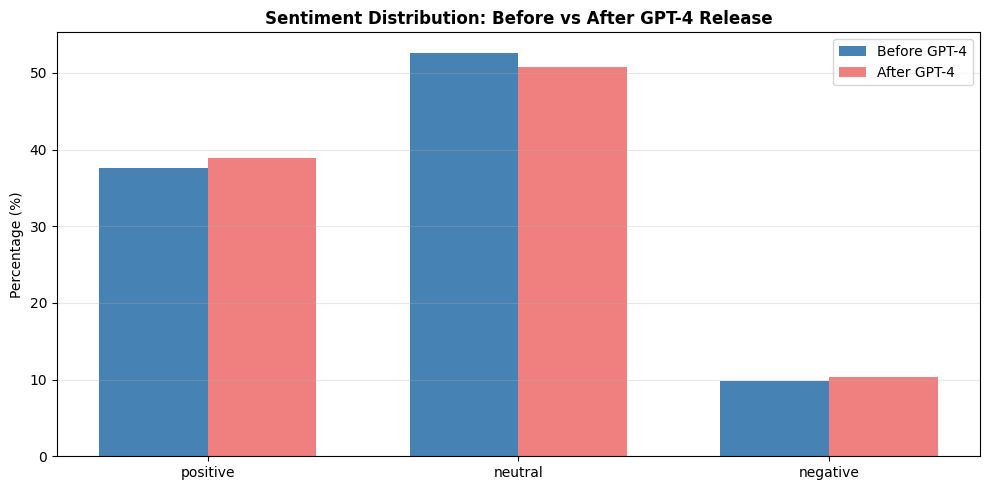

In [ ]:
before = all_df[all_df['date'] < pd.to_datetime('2023-03-14')]
after  = all_df[all_df['date'] >= pd.to_datetime('2023-03-14')]

before_pct = before['sentiment'].value_counts(normalize=True) * 100
after_pct  = after['sentiment'].value_counts(normalize=True) * 100

order = ['positive', 'neutral', 'negative']
x = range(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], [before_pct.get(s, 0) for s in order], width, label='Before GPT-4', color='steelblue')
ax.bar([i + width/2 for i in x], [after_pct.get(s, 0) for s in order],  width, label='After GPT-4',  color='lightcoral')

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel('Percentage (%)')
ax.set_title('Sentiment Distribution: Before vs After GPT-4 Release', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    all_df['sentiment'],
    all_df['date'].apply(lambda x: 'After' if x >= pd.to_datetime('2023-03-14') else 'Before')
)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.4f} | p-value: {p:.4f} | df: {dof}")
print("Statistically significant" if p < 0.05 else "Not statistically significant")

Chi-square: 59.8441 | p-value: 0.0000 | df: 2
Statistically significant


Following GPT-4's release, positive sentiment increased slightly (37.1% → 38.3%) while neutral declined (44.9% → 41.5%) and negative rose modestly (18.3% → 20.7%). Although the absolute differences are small, the chi-square test confirms these shifts are statistically significant (χ² = 59.84, p < 0.0001), indicating that GPT-4's release did meaningfully alter the sentiment distribution, generating both **more enthusiasm and more criticism**, while **reducing purely neutral engagement**.

# Module-4: Improvements

## Part-1: Address comments from previous check-in

**Sentiment Annotation**

Issue: Using a single LLM (ChatGPT) to label sentiment about GPT-4 raises concerns about annotation bias, particularly if the model might favor positive labels when discussing AI products.

Revision: Rather than defaulting to one model, I compared three independent LLMs (Claude, DeepSeek, and MiniMax) using Cohen's Kappa. Claude was selected as the final annotator based on the highest agreement with MiniMax (κ = 0.74) and the most balanced label distribution (neutral: 43%, positive: 37%, negative: 19%). Importantly, none of the three annotators are OpenAI models, which further mitigates the potential bias concern. Since all supervised learning results depend directly on these labels, this is one of the most consequential design decisions in the project.

## Part-2: Address comments from peer feedback

**Data Scope**

Issue: The original approach used the full dataset without any temporal constraints, making before/after comparisons unreliable as tweets far from the release date may reflect entirely different discourse contexts.

Revision: I filtered the dataset to a ±2-week window around GPT-4's release (March 1–27, 2023), resulting in 164,548 tweets. This controls for temporal confounds and improves the internal validity of all downstream analyses including topic modeling, sentiment classification, and the before/after statistical comparisons.

**Topic Modeling Method**

Issue: The original approach used K-Means clustering with PCA dimensionality reduction. After applying PCA, the explained variance was only 28%, meaning the reduced representation retained very little of the original information, which would produce unreliable clusters.

Revision: I replaced K-Means with BERTopic, which uses Sentence-BERT embeddings and UMAP for dimensionality reduction, both of which are designed for high-dimensional text data. The resulting 20 topics are semantically coherent (topic diversity score: 0.9850), and all downstream topic distribution and before/after comparisons are built on a more robust foundation.

**Topic Noise Filtering**

Issue: The raw BERTopic output contained substantial noise. Topic 0 alone covered over 87,000 tweets with no coherent theme, and topics T1, T3, T4, T7, T8, T9, T11, T13, T16 were identifiable as bot-generated or spam content.

Revision: I manually excluded these topics and retained only the 10 meaningful ones, ensuring the topic distribution analysis reflects genuine human discourse. A limitation of this approach is that it relies on manual inspection rather than systematic document-level filtering of T0. Future work should examine T0's internal structure for latent subtopics.

**Model Performance Limitation**

Issue: Model accuracy plateaus at approximately 61%, which may appear to suggest suboptimal model selection or tuning.

Revision: Following TA feedback, I added an explicit discussion clarifying that the performance ceiling is primarily a data issue rather than a model issue. After preprocessing, tweets average only 14.20 words, providing insufficient linguistic context for reliable sentiment inference. This revision sets appropriate expectations and motivates future directions such as transformer-based models (e.g., BERTweet, RoBERTa) that can better handle short and context-dependent text.